(05-27-drie-antwoorden)=

# Habit, long-run risk en rampen

```{admonition} Waar we zijn in het verhaal
:class: important

**Jaartal.** 1988–2013: van Rietz (1988) via Campbell en Cochrane (1999), Bansal
en Yaron (2004) en Barro (2006) tot Gabaix (2012) en Wachter (2013).

**Wat we al weten.** In [](#03-12-consumptie-capm) kreeg de discontovoet een
theorie, $m_{t+1} = \beta(c_{t+1}/c_t)^{-\gamma}$, en in
[](#03-13-equity-premium-puzzle) bleek die theorie de premie alleen te halen met
een risicoaversie in de dertig en een rente die dan absurd hoog wordt. In
[](#04-20-voorspelbaarheid) zagen we dat de prijs-dividend-ratio vooral
toekomstige rendementen voorspelt: de discontovoet beweegt, en een
Lucas-boom met CRRA-nut en iid groei kan dat niet. [](#05-26-sdf-unificatie)
maakte van elk model een uitspraak over één object, $m_{t+1}$.

**Welke vraag staat open.** Welke $m_{t+1}$, gebouwd uit consumptie, geeft
tegelijk een hoge premie, een lage en stabiele rente en een bewegende,
voorspellende prijs-dividend-ratio — en kunnen de data tussen de kandidaten
kiezen?
```

## Overzicht

Rond de eeuwwisseling kreeg de equity premium puzzle drie antwoorden die elk
werkten. Campbell en Cochrane {cite}`CampbellCochrane1999` gaven beleggers een
gewoonte: wie aan een levensstandaard gewend is, wordt in een recessie veel
risicomijdender, en eist dan een hoge premie. Bansal en Yaron
{cite}`BansalYaron2004` lieten de voorkeuren van Epstein en Zin
{cite}`EpsteinZin1989` los op een consumptieproces met een kleine, persistente
groeicomponent: beleggers vrezen nieuws over de verre toekomst. Barro
{cite}`Barro2006`, voortbouwend op Rietz {cite}`Rietz1988`, maakte de premie
een vergoeding voor zeldzame rampen die toevallig niet in de Amerikaanse
steekproef zitten. Santa-Clara vat de afloop in drie zinnen samen: *"Each fit.
Each required a parameter that could not be independently verified."* De modellen
zijn *"observationally equivalent on the available data"* {cite}`SantaClara2026`.

Dat maakt deze lecture tot het scharnier van motief 3. Het consumption CAPM was
een theorie die met één toets werd verworpen; hier staan drie theorieën die
dezelfde feiten reproduceren en elk een parameter nodig hebben — de
persistentie van de gewoonte, de persistentie van langetermijngroei, de kans op
een ramp — die met een eeuw data niet te meten is. De equity premium is een
*feit-met-concurrerende-theorieën* geworden. Chen, Dou en Kogan
{cite}`ChenDouKogan2024` gaven dat in 2024 een naam: *dark matter*
(donkere materie: de informatie die een model uit zijn eigen dwarsverbanden haalt
in plaats van uit de data), en een maat voor hoeveel ervan een model nodig heeft.

We rekenen eerst twee toy-voorbeelden met de hand: een Rietz-economie met twee toestanden en de Epstein-Zin-SDF in één stap. De theorie leidt per model de SDF, de premie en de bron van een bewegende prijs-dividend-ratio af. De simulatie lost de modellen numeriek op en vraagt welke momenten ze in honderd jaar data echt onderscheiden. De replicatie reproduceert kerngetallen van Campbell-Cochrane (via Wachter {cite}`Wachter2005`), Bansal-Yaron (via Beeler en Campbell {cite}`BeelerCampbell2012`) en Barro {cite}`Barro2009`, en plaatst de Amerikaanse data 1930–2025 in de banden van elk model.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import optimize

import hap
from hap import data as hap_data
hap.plotting.setup()

rng = np.random.default_rng(20240101)

## Intuïtie: waarom zou dit waar zijn?

De puzzel uit [](#03-13-equity-premium-puzzle) heeft twee helften. Consumptie
schommelt te weinig om een grote premie te rechtvaardigen, tenzij beleggers
extreem risicomijdend zijn. En als ze dat zijn, willen ze niet sparen terwijl
consumptie groeit, dus zou de rente hoog moeten zijn. Elk antwoord moet daarom
twee dingen tegelijk doen: de discontofactor in slechte toestanden veel groter
maken zonder hem gemiddeld te verlagen. De drie modellen doen dat op drie
plaatsen.

**Gewoonte.** Stel dat uw welzijn afhangt van hoeveel u consumeert *boven wat u gewend bent*. Wie 100 besteedt en aan 95 gewend is, heeft een marge van 5; een daling van 2% verkleint die marge met 40%. Voor zo'n belegger is een gewone recessie een ramp, en hoe dichter hij bij zijn gewoonte zit, hoe risicomijdender hij wordt. De premie is hoog in slechte tijden en laag in goede, dus prijzen dalen in recessies meer dan dividenden, en een lage prijs voorspelt hoge rendementen. Omdat een belegger dicht bij zijn gewoonte ook meer wil voorzorgssparen, kan de rente constant blijven.

**Langetermijnrisico.** Stel dat consumptiegroei een kleine component heeft die jaren aanhoudt: een tiende procentpunt meer of minder groei, tien jaar lang. In jaardata verdwijnt dat in de ruis. Maar een aandeel is een claim op alle toekomstige dividenden, en een blijvend lagere groei treft ze allemaal tegelijk. Wie liever vroeg weet waar hij aan toe is — een voorkeur voor *vroege resolutie van onzekerheid* — betaalt veel voor bescherming tegen zulk nieuws. Epstein-Zin-voorkeuren maken dat mogelijk door risicoaversie los te koppelen van de bereidheid om consumptie door de tijd te verschuiven: een hoge risicoaversie voor de premie, een hoge intertemporele substitutie voor de lage rente.

**Rampen.** Stel dat de wereld elk jaar een kleine kans heeft op een catastrofe:
een oorlog of depressie waarin consumptie met een kwart of meer daalt. In zo'n
jaar is een extra euro enorm veel waard, aandelen storten in, en obligaties
betalen gewoon uit. Een kans van anderhalf procent per jaar is genoeg voor een
premie van een paar procent. En omdat iedereen zich tegen die ramp wil indekken,
is de vraag naar veilige obligaties groot en de rente laag. In honderd jaar
Amerikaanse data zit zo'n ramp niet — en precies daarom ziet de premie er te
groot uit voor het risico dat we *zagen*.

Nu het ongemakkelijke deel. Alle drie de verhalen passen op dezelfde handvol
getallen: de gemiddelde premie, de volatiliteit, de lage rente, de beweeglijke
prijs-dividend-ratio. Wat ze onderscheidt, is iets wat we niet goed kunnen meten:
hoe snel een gewoonte zich aanpast, hoe persistent een groeicomponent is die in de
ruis verdwijnt, en hoe vaak rampen voorkomen die in de steekproef niet
voorkwamen. Het 2%-motief krijgt hier zijn scherpste vorm: als gemiddelden al
slecht gemeten zijn, zijn zeldzame gebeurtenissen en trage componenten het nog
veel slechter.

## Toy-voorbeeld: een ramp met de hand, en Epstein-Zin in één stap

### (a) Rietz-Barro met twee toestanden

Consumptie is het dividend van de boom. Elk jaar groeit ze met $g_n = 1{,}025$
(normaal) of krimpt ze met $b = 40\%$, dus $g_d = 0{,}60$ (ramp), onafhankelijk
door de tijd. Barro schrijft dat bij $\gamma = 4$ een constante daling van
ongeveer 40% dezelfde premie geeft als de empirische verdeling van rampgroottes
{cite}`Barro2009`. De kans op een ramp is $p = 0{,}017$, Barro's frequentie van 60
rampen in 35 landen in een eeuw. Voorkeuren zijn CRRA met $\gamma = 4$ en
$\beta = 0{,}97$.

**De SDF.** $m = \beta g^{-4}$. Met $1{,}025^4 = 1{,}103813$ is
$m_n = 0{,}97/1{,}103813 = 0{,}878770$; met $0{,}6^4 = 0{,}1296$ is
$m_d = 0{,}97/0{,}1296 = 7{,}484568$. In een ramp is een euro achtenhalf keer zoveel
waard als normaal.

**Zonder ramp** ($p = 0$). Er is geen risico: $R^f = 1/m_n = 1{,}1380$, een rente van
13,8%, de risicovrije-rentepuzzel van [](#eq-equity-premium-puzzle-eis). Het aandeel
is risicovrij, dus de premie is nul. De prijs-dividend-ratio is
$k/(1-k)$ met $k = \beta g_n^{-3} = 0{,}97 \times 0{,}928599 = 0{,}900741$, dus
$\mathrm{PD} = 9{,}07$.

**Met ramp** ($p = 0{,}017$). De verwachte SDF is
$\E[m] = 0{,}983 \times 0{,}878770 + 0{,}017 \times 7{,}484568 = 0{,}863831 + 0{,}127238
= 0{,}991069$, dus $R^f = 1{,}00901$: de rente zakt van 13,8% naar 0,9%. Voor het aandeel:
$k = \beta\,\E[g^{-3}] = 0{,}97\,(0{,}983 \times 0{,}928599 + 0{,}017 \times 4{,}629630) = 0{,}961772$,
dus $\mathrm{PD} = 25{,}16$. Het verwachte rendement is
$\E[g]/k = (0{,}983 \times 1{,}025 + 0{,}017 \times 0{,}6)/0{,}961772 = 1{,}017775/0{,}961772
= 1{,}05823$, en de premie $5{,}823 - 0{,}901 = 4{,}92$ procentpunt.

**Het peso-probleem.** In een steekproef zonder ramp verdient het aandeel elk jaar
$g_n/k = 1{,}025/0{,}961772 = 1{,}06574$, dus 5,67 procentpunt boven de rente — nog
meer dan de ware premie. De kans dat honderd jaar geen enkele ramp bevatten is
$0{,}983^{100} = 0{,}18$.

In [2]:
beta_a, gamma_a, g_n, b_toy, p_toy = 0.97, 4.0, 1.025, 0.40, 0.017
growth_toy = np.array([g_n, 1 - b_toy])


def rietz_toy(p):
    """Two-state iid Lucas tree: returns R^f, P/D, E[R] and the premium."""
    prob = np.array([1 - p, p])
    m = beta_a * growth_toy ** -gamma_a
    k = beta_a * prob @ growth_toy ** (1 - gamma_a)
    rf = 1 / (prob @ m)
    er = (prob @ growth_toy) / k
    return {"m_n": m[0], "m_d": m[1], "R^f": rf, "P/D": k / (1 - k), "E[R]": er, "premie (%)": 100 * (er - rf),
            "R zonder ramp": g_n / k}


toy_a = pd.DataFrame({"p = 0": rietz_toy(0.0), "p = 0,017": rietz_toy(p_toy)}).T
print("met de hand: R^f = 1.1380 / 1.00901, P/D = 9.07 / 25.16, premie = 0 / 4.92%, R zonder ramp 1.06574")
print(f"kans op 100 jaar zonder ramp: {(1 - p_toy) ** 100:.3f}")
toy_a.round(5)

met de hand: R^f = 1.1380 / 1.00901, P/D = 9.07 / 25.16, premie = 0 / 4.92%, R zonder ramp 1.06574
kans op 100 jaar zonder ramp: 0.180


,m_n,m_d,R^f,P/D,E[R],premie (%),R zonder ramp
p = 0,0.87877,7.48457,1.13795,9.07470,1.13795,0.00000,1.13795
"p = 0,017",0.87877,7.48457,1.00901,25.15844,1.05823,4.92198,1.06574


De code reproduceert de handberekening. Een kans van 1,7% per jaar verandert
de economie van een wereld met een rente van 13,8% en geen premie in een wereld
met een rente onder de 1% en een premie van bijna 5%, bij dezelfde $\gamma$. De
gemiddelde consumptiegroei daalt daarbij maar van 2,5% naar 1,8%.

### (b) De Epstein-Zin-SDF in één stap

Neem Epstein-Zin-voorkeuren met risicoaversie $\gamma$ en intertemporele
substitutie-elasticiteit $\psi$, en een iid lognormale economie:
$\Delta c_{t+1} \sim N(\mu, \sigma^2)$. De SDF (die we in de theorie afleiden) is

$$
\log m_{t+1} = \theta\log\beta - \frac{\theta}{\psi}\Delta c_{t+1} + (\theta - 1)\, r_{w,t+1},
\qquad \theta = \frac{1-\gamma}{1 - 1/\psi},
$$

met $r_w$ het log-rendement op de claim op alle toekomstige consumptie. Bij iid
groei is de vermogen-consumptieverhouding constant, dus $r_{w,t+1} = \Delta c_{t+1} + \kappa$
voor een constante $\kappa$. De helling van $\log m$ op $\Delta c$ is dan
$-\theta/\psi + \theta - 1 = \theta(1 - 1/\psi) - 1 = -\gamma$. Uitwerken (oefening 1)
geeft

$$
\log R^f = -\log\beta + \frac{\mu}{\psi} - \tfrac12\sigma^2\gamma\Big(1 + \frac1\psi\Big) + \frac{\sigma^2}{2\psi},
\qquad
\log\frac{\E[R_w]}{R^f} = \gamma\sigma^2 .
$$

Met $\beta = 0{,}98$, $\mu = \sigma = 0{,}02$ en $\gamma = 10$:

- bij $\psi = 1{,}5$ is $\log R^f = 0{,}020203 + 0{,}013333 - 0{,}003333 + 0{,}000133 = 0{,}030336$, een rente van 3,0%;
- bij $\psi = 1/\gamma = 0{,}1$ (CRRA) is $\log R^f = 0{,}020203 + 0{,}2 - 0{,}022 + 0{,}002 = 0{,}200203$, een rente van 20%;
- in beide gevallen is de premie $\gamma\sigma^2 = 10 \times 0{,}0004 = 0{,}40$ procentpunt.

$\psi$ verplaatst de rente en laat de premie ongemoeid; $\gamma$ verplaatst de
premie. Dat is Weils ontkoppeling uit [](#03-13-equity-premium-puzzle) in één
regel — en het laat ook zien wat Epstein-Zin *niet* doet: bij iid groei blijft de
premie $\gamma\sigma^2$, even klein als bij CRRA. Pas als groei voorspelbaar is,
krijgt $\psi$ invloed op de premie. Dat is de bijdrage van Bansal en Yaron.

In [3]:
def ez_iid(beta, mu, sigma, gamma, psi):
    """Log risk-free rate and log premium on the wealth claim, iid lognormal growth."""
    log_rf = -np.log(beta) + mu / psi - 0.5 * sigma**2 * gamma * (1 + 1 / psi) + 0.5 * sigma**2 / psi
    return log_rf, gamma * sigma**2


toy_b = {}
for gamma_b, psi_b in [(10, 1.5), (10, 0.1), (5, 1.5), (5, 0.2)]:
    log_rf, prem = ez_iid(0.98, 0.02, 0.02, gamma_b, psi_b)
    toy_b[f"gamma = {gamma_b}, psi = {psi_b}"] = {"log R^f": log_rf, "log premie": prem}

# check the closed form against a brute-force Euler equation with the SDF above
theta = (1 - 10) / (1 - 1 / 1.5)
z = rng.standard_normal(2_000_000)
dc = 0.02 + 0.02 * z
kappa = -np.log(0.98) - ((1 - 10) * 0.02 + 0.5 * (1 - 10) ** 2 * 0.02**2) / theta
log_m = theta * np.log(0.98) - theta / 1.5 * dc + (theta - 1) * (dc + kappa)
print(f"E[m R_w] = {np.mean(np.exp(log_m + dc + kappa)):.4f}  (moet 1 zijn)")
print(f"log R^f uit simulatie = {-np.log(np.mean(np.exp(log_m))):.4f}  (met de hand: 0.0303)")
pd.DataFrame(toy_b).T.round(6)

E[m R_w] = 1.0002  (moet 1 zijn)
log R^f uit simulatie = 0.0301  (met de hand: 0.0303)


,log R^f,log premie
"gamma = 10, psi = 1.5",0.030336,0.004
"gamma = 10, psi = 0.1",0.200203,0.004
"gamma = 5, psi = 1.5",0.032003,0.002
"gamma = 5, psi = 0.2",0.115203,0.002


Rij één en twee geven 0,030336 en 0,200203, de handgetallen; de Monte-Carlo-controle
bevestigt dat de SDF de claim op consumptie precies op één prijst. Rij drie en vier
herhalen de les bij $\gamma = 5$: de premie halveert, en de rente hangt vooral aan
$\psi$.

## Theorie

### Drie SDF's in één schema

*Waarom zou dit waar zijn?* Uit [](#eq-equity-premium-puzzle-hj) weten we dat een
SDF een Sharpe-ratio van ongeveer 0,4 moet kunnen dragen: $\sigma(m)/\E[m] \geq 0{,}4$.
Met CRRA is $\sigma(\log m) = \gamma\sigma(\Delta c)$, en consumptie schommelt maar
een paar procent. Er zijn dus maar drie uitwegen. Maak de vermenigvuldiger van
$\Delta c$ groter in slechte tijden (gewoonte). Laat $m$ reageren op iets dat groter
is dan de consumptieschok van dit jaar: het nieuws over alle toekomstige jaren
(langetermijnrisico). Of geef $\Delta c$ zelf een staart die in de steekproef niet
te zien is (rampen).

| | SDF $m_{t+1}$ | prijs van risico | vrije, moeilijk meetbare parameter |
|---|---|---|---|
| Campbell-Cochrane | $\beta\,(S_{t+1}C_{t+1}/S_tC_t)^{-\gamma}$ | $\gamma\,\sigma\,(1 + \lambda(s_t))$ | persistentie $\phi$ van de gewoonte |
| Bansal-Yaron | $\beta^\theta G_{t+1}^{-\theta/\psi} R_{w,t+1}^{\theta-1}$ | $\gamma$, $\lambda_e$, $\lambda_w$ | persistentie $\rho$ van $x_t$ |
| Rietz-Barro | $\beta\, G_{t+1}^{-\gamma}$ met sprongen | $\gamma\sigma$ plus sprongterm | rampkans $p$ en -grootte $b$ |

Notatie: we schrijven $G_{t+1} = C_{t+1}/C_t$ en $\Delta c_{t+1} = \log G_{t+1}$.
Campbell en Cochrane schrijven $\delta$ voor $\beta$; Bansal en Yaron schrijven
$\delta$ voor $\beta$ en $g_{t+1}$ voor $\Delta c_{t+1}$; Barro schrijft $\rho$ voor
de tijdsvoorkeur, met $\beta = e^{-\rho}$.

### Campbell-Cochrane: de surplus consumption ratio

*Waarom zou dit waar zijn?* Als nut afhangt van $C_t - X_t$, met $X_t$ een
gewoonte die de belegger als gegeven neemt (*external habit*: de gewoonte wordt
bepaald door de consumptie van anderen, "keeping up with the Joneses"), dan is de
curvatuur ten opzichte van $C_t$ niet $\gamma$ maar $\gamma C_t/(C_t - X_t)$. Een
kleine marge boven de gewoonte maakt de belegger lokaal zeer risicomijdend,
zonder dat $\gamma$ zelf groot is.

Definieer de *surplus consumption ratio* (surplusratio: het deel van consumptie
boven de gewoonte) $S_t = (C_t - X_t)/C_t$ en $s_t = \log S_t$. Met nut
$\E_0\sum_t \beta^t (C_t - X_t)^{1-\gamma}/(1-\gamma)$ is marginaal nut
$(C_t - X_t)^{-\gamma} = (S_tC_t)^{-\gamma}$, want de gewoonte is extern. De SDF is dus

```{math}
:label: eq-drie-antwoorden-cc-sdf
m_{t+1} = \beta\left(\frac{S_{t+1}C_{t+1}}{S_t C_t}\right)^{-\gamma},
\qquad
\log m_{t+1} = \log\beta - \gamma\,(\Delta s_{t+1} + \Delta c_{t+1}),
```

en de lokale risicoaversie is $-C u''/u' = \gamma/S_t$. Campbell en Cochrane geven
$\Delta c_{t+1} = g + v_{t+1}$ met $v \sim N(0, \sigma^2)$ iid, en leggen de gewoonte
vast via

```{math}
:label: eq-drie-antwoorden-cc-s
s_{t+1} = (1-\phi)\,\bar s + \phi\, s_t + \lambda(s_t)\, v_{t+1} .
```

De *sensitivity function* $\lambda(s_t)$ (gevoeligheidsfunctie: hoe sterk het
surplus op een consumptieschok reageert) is het vrije ontwerp van het model.
Campbell en Cochrane kozen hem zó dat drie dingen gelden: de rente is constant,
de gewoonte beweegt lokaal niet mee met consumptie rond de steady state, en
$X_t$ blijft onder $C_t$.

:::{prf:proposition} Constante rente in het habit-model
:label: prf-drie-antwoorden-cc-rente

Met [](#eq-drie-antwoorden-cc-sdf), [](#eq-drie-antwoorden-cc-s) en

```{math}
:label: eq-drie-antwoorden-cc-lambda
\lambda(s_t) = \frac{1}{\bar S}\sqrt{1 - 2(s_t - \bar s)} - 1 \quad (s_t \leq s_{\max}),
\qquad
\bar S = \sigma\sqrt{\frac{\gamma}{1-\phi}},
\qquad
s_{\max} = \bar s + \tfrac12(1 - \bar S^2),
```

en $\lambda = 0$ boven $s_{\max}$, is de log risicovrije rente constant:

```{math}
:label: eq-drie-antwoorden-cc-rf
r^f = -\log\beta + \gamma g - \tfrac12\gamma(1-\phi) .
```
:::

:::{prf:proof}
Uit [](#eq-drie-antwoorden-cc-sdf) en [](#eq-drie-antwoorden-cc-s) is
$\log m_{t+1} = \log\beta - \gamma g - \gamma(1-\phi)(\bar s - s_t) - \gamma(1 + \lambda(s_t))v_{t+1}$,
voorwaardelijk normaal. Dus

$$
r^f_t = -\log\E_t[m_{t+1}] = -\log\beta + \gamma g + \gamma(1-\phi)(\bar s - s_t)
- \tfrac12\gamma^2\sigma^2(1 + \lambda(s_t))^2 .
$$

Invullen van $(1 + \lambda)^2 = (1 - 2(s_t - \bar s))/\bar S^2$ en
$\bar S^2 = \gamma\sigma^2/(1-\phi)$ geeft
$\tfrac12\gamma^2\sigma^2(1+\lambda)^2 = \tfrac12\gamma(1-\phi)(1 - 2(s_t - \bar s))$,
en de termen in $s_t$ vallen tegen elkaar weg. $\square$
:::

Het bewijs laat het mechanisme zien. Een laag surplus ($s_t < \bar s$) betekent dat
het surplus verwacht te herstellen: marginaal nut daalt, beleggers willen lenen,
en de rente zou stijgen (*intertemporele substitutie*). Tegelijk is $\lambda$ groot,
dus de SDF volatiel, en willen beleggers sparen (*voorzorg*). De functie
[](#eq-drie-antwoorden-cc-lambda) is precies zo gekozen dat die twee elkaar opheffen.
De maximale Sharpe-ratio is $\sigma(m)/\E[m] \approx \gamma\sigma(1 + \lambda(s_t))$:
in de steady state $\gamma\sigma/\bar S = \sqrt{\gamma(1-\phi)}$, hoger in
recessies. Dat is de tijdvariërende risicoaversie $\gamma/S_t$ in actie.

**De kalibratie.** Campbell en Cochrane kozen jaarparameters $g = 1{,}89\%$,
$\sigma = 1{,}50\%$, $r^f = 0{,}94\%$, $\phi = 0{,}87$ en $\gamma = 2$, en simuleerden
maandelijks. Hun eigen tabel 1 hebben we niet kunnen inzien; deze waarden staan
in tabel 1 van Wachter {cite}`Wachter2005`, die ook $\beta \approx 0{,}90$ vermeldt.
Het is $\phi$ die de kalibratie draagt: Campbell en Cochrane kozen hem om de
persistentie van de prijs-dividend-ratio te matchen, niet uit een onafhankelijke
meting van hoe snel gewoontes zich aanpassen.

**Prijzen.** Omdat $s_t$ de enige toestandsvariabele is, is de
prijs-consumptieverhouding een functie $\mathrm{PC}(s)$ die de Euler-vergelijking
oplost:

```{math}
:label: eq-drie-antwoorden-cc-pd
\mathrm{PC}(s_t) = \E_t\!\left[m_{t+1}\, G_{t+1}\,\big(1 + \mathrm{PC}(s_{t+1})\big)\right].
```

Er is geen gesloten vorm. Campbell en Cochrane itereerden op een rooster;
Wachter {cite}`Wachter2005` schreef de prijs als een som van *zero-coupon
equity*-claims en liet zien dat de oplossing gevoelig is voor het rooster. Omdat
[](#eq-drie-antwoorden-cc-pd) lineair is in $\mathrm{PC}$, lossen wij hem op een
rooster in één keer op als lineair stelsel $(\mathbf{I} - \mathbf{M})\,\mathbf{pc} = \mathbf{M}\mathbf{1}$,
met $\mathbf{M}$ de kwadratuur- en interpolatiegewichten.

### Epstein-Zin en de SDF

*Waarom zou dit waar zijn?* Tijd-separabel CRRA-nut gebruikt één kromming voor
twee afkeren: van schommelingen tussen toestanden en van schommelingen door de
tijd. Epstein en Zin {cite}`EpsteinZin1989` en Weil {cite}`Weil1989` definieerden
het nut recursief, zodat de kromming over morgen ($\gamma$) en de kromming over
de tijd ($1/\psi$) twee parameters worden. Omdat het nut van morgen dan
afhangt van het *hele* verdere pad, telt voor de SDF niet alleen consumptie van
morgen, maar ook het rendement op vermogen.

Het nut is

```{math}
:label: eq-drie-antwoorden-ez-nut
U_t = \left[(1-\beta)\,C_t^{1-1/\psi} + \beta\left(\E_t\!\left[U_{t+1}^{1-\gamma}\right]\right)^{\frac{1-1/\psi}{1-\gamma}}\right]^{\frac{1}{1-1/\psi}} .
```

:::{prf:proposition} De Epstein-Zin-SDF
:label: prf-drie-antwoorden-ez-sdf

Laat $R_{w,t+1}$ het rendement zijn op de claim op de hele consumptiestroom en
$\theta = (1-\gamma)/(1-1/\psi)$. Dan is

```{math}
:label: eq-drie-antwoorden-ez-sdf
m_{t+1} = \beta^\theta\, G_{t+1}^{-\theta/\psi}\, R_{w,t+1}^{\theta - 1} .
```

Bij $\gamma = 1/\psi$ is $\theta = 1$ en is dit de CRRA-SDF.
:::

:::{prf:proof}
:class: dropdown

*Schets.* Homogeniteit geeft $U_t = \Phi_t W_t$ met $W_t$ vermogen inclusief de
consumptie van vandaag, en de budgetrestrictie $W_{t+1} = (W_t - C_t)R_{w,t+1}$.
De eerste-ordevoorwaarde naar $C_t$ en de envelopstelling geven
$\partial U_t/\partial W_t = (1-\beta)U_t^{1/\psi}C_t^{-1/\psi}$. De marginale
waardering van een euro op $t+1$ ten opzichte van $t$ is dan

$$
m_{t+1} = \beta \left(\frac{C_{t+1}}{C_t}\right)^{-1/\psi}
\left(\frac{U_{t+1}}{\big(\E_t[U_{t+1}^{1-\gamma}]\big)^{1/(1-\gamma)}}\right)^{1/\psi - \gamma} .
$$

De tweede factor, met $\mathcal{R}_t = (\E_t[U_{t+1}^{1-\gamma}])^{1/(1-\gamma)}$ het
zekerheidsequivalent van het vervolgnut, is de correctie voor risico over de
hele toekomst. Hij is niet waarneembaar, maar homogeniteit en de
Euler-vergelijking voor het vermogensrendement geven
$(U_{t+1}/\mathcal{R}_t)^{1-1/\psi} = \beta\, G_{t+1}^{-1/\psi} R_{w,t+1}$
{cite}`EpsteinZin1989,Weil1989`. Controle: zonder risico is $U_{t+1} = \mathcal{R}_t$
en staat er de gewone Euler-vergelijking $R_w = G^{1/\psi}/\beta$. Verheffen tot de
macht $(1/\psi - \gamma)/(1 - 1/\psi) = \theta - 1$ en invullen geeft
$m_{t+1} = \beta\, G^{-1/\psi}\,\big(\beta\, G^{-1/\psi}R_w\big)^{\theta-1} = \beta^\theta G^{-\theta/\psi}R_w^{\theta-1}$.
$\square$
:::

In logs is $\log m_{t+1} = \theta\log\beta - (\theta/\psi)\Delta c_{t+1} + (\theta-1)r_{w,t+1}$,
de vorm uit het toy-voorbeeld. Bij $\gamma > 1/\psi$ is $\theta < 0$, dus
$\theta - 1 < 0$: een slecht rendement op vermogen verhoogt de SDF. Nieuws dat de
waarde van de hele toekomstige consumptiestroom verlaagt, wordt beprijsd, ook als
het consumptie van dit jaar niet raakt. De belegger heeft een voorkeur voor vroege
resolutie van onzekerheid precies wanneer $\gamma > 1/\psi$.

### Bansal-Yaron: langetermijnrisico via de Campbell-Shiller-loglinearisatie

*Waarom zou dit waar zijn?* Een persistente groeicomponent $x_t$ verandert de
waarde van een claim op alle toekomstige consumptie met een factor die groeit met
de persistentie: een schok die $\rho^j$ jaren nawerkt, telt $1/(1-\rho)$ keer. Bij
$\psi > 1$ domineert het groei-effect het rente-effect, stijgen prijzen bij goed
groeinieuws, en is het vermogensrendement dus laag precies als de toekomst
verslechtert. Met $\theta - 1 < 0$ maakt dat de SDF hoog in die toestanden.

Bansal en Yaron schrijven, maandelijks,

```{math}
:label: eq-drie-antwoorden-by-proces
\begin{aligned}
\Delta c_{t+1} &= \mu + x_t + \sigma_t\eta_{t+1}, &
x_{t+1} &= \rho x_t + \varphi_e\sigma_t e_{t+1}, \\
\Delta d_{t+1} &= \mu_d + \phi x_t + \varphi_d\sigma_t u_{t+1}, &
\sigma^2_{t+1} &= \bar\sigma^2 + \nu_1(\sigma^2_t - \bar\sigma^2) + \sigma_w w_{t+1},
\end{aligned}
```

met onafhankelijke standaardnormale schokken. De kalibratie (tabel I van Beeler en
Campbell {cite}`BeelerCampbell2012`, die de parameters van Bansal en Yaron
overnemen): $\beta = 0{,}998$, $\gamma = 10$, $\psi = 1{,}5$, $\mu = \mu_d = 0{,}0015$,
$\rho = 0{,}979$, $\varphi_e = 0{,}044$, $\bar\sigma = 0{,}0078$, $\nu_1 = 0{,}987$,
$\sigma_w = 0{,}0000023$, $\phi = 3$ en $\varphi_d = 4{,}5$. Een halfwaardetijd van
$x_t$ van $\ln 2/-\ln 0{,}979 = 33$ maanden, en een standaarddeviatie van $x_t$ van
0,17 procentpunt per maand: in jaardata onzichtbaar klein.

Voor de loglinearisatie gebruiken we [](#eq-voorspelbaarheid-cs-rendement) uit
[](#04-20-voorspelbaarheid), nu voor de claim op consumptie:
$r_{w,t+1} = \kappa_0 + \kappa_1 z_{t+1} - z_t + \Delta c_{t+1}$ met $z_t$ de log
prijs-consumptieverhouding. (Vanaf hier zijn kleine letters logs.)

:::{prf:proposition} Oplossing van het long-run-risks-model
:label: prf-drie-antwoorden-by

Stel $z_t = A_0 + A_1 x_t + A_2\sigma^2_t$ en $z_{m,t} = A_{0,m} + A_{1,m}x_t + A_{2,m}\sigma^2_t$
voor de log prijs-dividendverhouding. De Euler-vergelijkingen voor $R_w$ en $R_m$ zijn
tot op de loglinearisatie exact vervuld met

```{math}
:label: eq-drie-antwoorden-by-A
A_1 = \frac{1 - 1/\psi}{1 - \kappa_1\rho},
\qquad
A_2 = \frac{\tfrac12\big[(1-\gamma)^2 + (\theta\kappa_1 A_1\varphi_e)^2\big]}{\theta(1 - \kappa_1\nu_1)},
\qquad
A_{1,m} = \frac{\phi - 1/\psi}{1 - \kappa_{1,m}\rho},
```

en de innovatie in de SDF is

```{math}
:label: eq-drie-antwoorden-by-sdf
m_{t+1} - \E_t m_{t+1} = -\gamma\,\sigma_t\eta_{t+1} - \lambda_e\,\sigma_t e_{t+1} - \lambda_w\,\sigma_w w_{t+1},
\qquad
\lambda_e = (1-\theta)\kappa_1 A_1\varphi_e,
\quad
\lambda_w = (1-\theta)\kappa_1 A_2 .
```

De verwachte log excess return op de markt (inclusief de Jensen-term) is

```{math}
:label: eq-drie-antwoorden-by-premie
\E_t[r_{m,t+1} - r^f_t] + \tfrac12\Var_t(r_{m,t+1})
= \underbrace{\lambda_e\,\kappa_{1,m}A_{1,m}\varphi_e\,\sigma^2_t}_{\text{langetermijnrisico}}
\;+\; \underbrace{\lambda_w\,\kappa_{1,m}A_{2,m}\,\sigma^2_w}_{\text{volatiliteitsrisico}} .
```
:::

:::{prf:proof}
:class: dropdown

Schrijf $\log m_{t+1} + r_{w,t+1} = \theta\log\beta - (\theta/\psi)\Delta c_{t+1} + \theta r_{w,t+1}$
en vul $r_w$ en [](#eq-drie-antwoorden-by-proces) in. Het resultaat is voorwaardelijk
normaal, dus $\E_t[e^{m+r_w}] = 1$ is equivalent met: voorwaardelijk gemiddelde plus
de helft van de voorwaardelijke variantie is nul. Dat moet gelden voor elke $x_t$
en $\sigma^2_t$, dus de coëfficiënten moeten afzonderlijk nul zijn.

*Coëfficiënt van $x_t$:* $\theta\kappa_1A_1\rho - \theta A_1 + \theta(1 - 1/\psi) = 0$,
dus $A_1 = (1-1/\psi)/(1-\kappa_1\rho)$.

*Coëfficiënt van $\sigma^2_t$:* uit het gemiddelde $\theta(\kappa_1\nu_1 - 1)A_2$, uit
de variantie $\tfrac12[\theta^2(1-1/\psi)^2 + \theta^2\kappa_1^2A_1^2\varphi_e^2]$.
Gebruik $\theta(1-1/\psi) = 1-\gamma$ en los op naar $A_2$.

*SDF.* De innovatie van $\log m$ is $-(\theta/\psi)\sigma_t\eta + (\theta-1)(\sigma_t\eta +
\kappa_1A_1\varphi_e\sigma_te + \kappa_1A_2\sigma_ww)$; de coëfficiënt van
$\sigma_t\eta$ is $\theta(1-1/\psi) - 1 = -\gamma$.

*Markt.* Herhaal voor $\log m_{t+1} + r_{m,t+1}$. De $x_t$-coëfficiënt van $\log m$ is
$-1/\psi$ (want $\kappa_1A_1\rho - A_1 + 1 = 1/\psi$), die van $r_m$ is
$\kappa_{1,m}A_{1,m}\rho - A_{1,m} + \phi$; hun som nul geeft $A_{1,m}$. Tot slot is
$\E_t[r_m] - r^f + \tfrac12\Var_t(r_m) = -\Cov_t(m, r_m)$, en de enige schokken die
$m$ en $r_m$ delen zijn $e$ en $w$, met ladingen $(-\lambda_e, \kappa_{1,m}A_{1,m}\varphi_e)$
en $(-\lambda_w, \kappa_{1,m}A_{2,m})$. $\square$
:::

Drie observaties. Ten eerste: $A_1 > 0$ vereist $\psi > 1$. Met $\psi < 1$ dalen
prijzen bij goed groeinieuws, verandert het teken van $\lambda_e$, en verdwijnt de
premie; de EIS die Bansal en Yaron nodig hebben, ligt boven de meeste
macro-econometrische schattingen, die zij als vertekend door tijdvariërende
volatiliteit beschouwen. Ten tweede: de premie loopt via de *lading* van het
rendement op $x_t$, $\kappa_{1,m}A_{1,m}\varphi_e$, en die is groot omdat $A_{1,m}$
een factor $1/(1-\kappa_{1,m}\rho) \approx 40$ bevat. Met $\phi = 3$ is dividendgroei
drie keer zo gevoelig voor $x_t$ als consumptie: *leverage* op langetermijnrisico.
Ten derde: de rente is lineair in $x_t$ en $\sigma^2_t$, dus niet constant maar wel glad, en de persistentie $\rho$ bepaalt vrijwel alles — een parameter die honderd jaar jaardata nauwelijks kunnen vastleggen, omdat $x_t$ zelf niet waarneembaar is.

In [4]:
BY = dict(beta=0.998, gamma=10.0, psi=1.5, mu=0.0015, rho=0.979, phi_e=0.044, sig=0.0078, nu1=0.987,
          sig_w=0.0000023, mu_d=0.0015, phi=3.0, phi_d=4.5)          # monthly, Beeler-Campbell (2012) Table I


def by_solve(p):
    """Log-linear solution of Bansal-Yaron (2004) with endogenous linearisation constants."""
    beta, gamma, psi, mu, rho = p["beta"], p["gamma"], p["psi"], p["mu"], p["rho"]
    pe, s2, nu, sw = p["phi_e"], p["sig"] ** 2, p["nu1"], p["sig_w"]
    theta = (1 - gamma) / (1 - 1 / psi)
    kappas = lambda z: (np.log1p(np.exp(z)) - np.exp(z) / (1 + np.exp(z)) * z, np.exp(z) / (1 + np.exp(z)))

    def wealth(z):
        k0, k1 = kappas(z)
        A1 = (1 - 1 / psi) / (1 - k1 * rho)
        A2 = 0.5 * ((1 - gamma) ** 2 + (theta * k1 * A1 * pe) ** 2) / (theta * (1 - k1 * nu))
        A0 = (np.log(beta) + k0 + k1 * A2 * s2 * (1 - nu) + (1 - 1 / psi) * mu + 0.5 * theta * (k1 * A2 * sw) ** 2) / (1 - k1)
        return k0, k1, A0, A1, A2

    z = optimize.brentq(lambda z: wealth(z)[2] + wealth(z)[4] * s2 - z, 0.5, 15)
    k0, k1, A0, A1, A2 = wealth(z)
    lam_e, lam_w = (1 - theta) * k1 * A1 * pe, (1 - theta) * k1 * A2
    m0 = theta * np.log(beta) - theta / psi * mu + (theta - 1) * (k0 + k1 * A0 + k1 * A2 * s2 * (1 - nu) - A0 + mu)
    ms = (theta - 1) * A2 * (k1 * nu - 1)

    def market(z):
        k0m, k1m = kappas(z)
        A1m = (p["phi"] - 1 / psi) / (1 - k1m * rho)
        A2m = (ms + 0.5 * (gamma**2 + p["phi_d"] ** 2 + (k1m * A1m * pe - lam_e) ** 2)) / (1 - k1m * nu)
        A0m = (m0 + k0m + k1m * A2m * s2 * (1 - nu) + p["mu_d"] + 0.5 * sw**2 * (k1m * A2m - lam_w) ** 2) / (1 - k1m)
        return k0m, k1m, A0m, A1m, A2m

    zm = optimize.brentq(lambda z: market(z)[2] + market(z)[4] * s2 - z, 0.5, 15)
    k0m, k1m, A0m, A1m, A2m = market(zm)
    return dict(p=p, theta=theta, A1=A1, A2=A2, k1=k1, A0m=A0m, A1m=A1m, A2m=A2m, k0m=k0m, k1m=k1m,
                lam_e=lam_e, lam_w=lam_w, m0=m0, mx=-1 / psi, ms=ms)


by = by_solve(BY)
prem_lrr = by["lam_e"] * by["k1m"] * by["A1m"] * BY["phi_e"] * BY["sig"] ** 2
prem_vol = by["lam_w"] * by["k1m"] * by["A2m"] * BY["sig_w"] ** 2
pd.Series({"theta": by["theta"], "A_1": by["A1"], "A_1,m": by["A1m"], "kappa_1,m": by["k1m"],
           "lambda_e": by["lam_e"], "premie via x_t (%/jaar)": 1200 * prem_lrr,
           "premie via sigma_t (%/jaar)": 1200 * prem_vol}).round(3)

theta                         -27.000
A_1                            14.555
A_1,m                          93.218
kappa_1,m                       0.996
lambda_e                       17.897
premie via x_t (%/jaar)         5.337
premie via sigma_t (%/jaar)     0.199
dtype: float64

Bij de kalibratie van Bansal en Yaron is $\theta = -27$ en $A_{1,m} \approx 93$: een
stijging van $x_t$ met één standaarddeviatie (0,0017) verhoogt de log
prijs-dividendverhouding met 0,16. Vrijwel de hele premie komt uit het
langetermijnkanaal; het volatiliteitskanaal draagt minder dan een tiende bij
(beide termen zijn positief, want $\lambda_w$ en $A_{2,m}$ zijn allebei negatief: hogere
onzekerheid verlaagt prijzen en verhoogt de SDF).

### Rietz-Barro: CRRA met sprongen

*Waarom zou dit waar zijn?* Een ramp is een enorme stijging van marginaal nut. Een
aandeel verliest dan $b$ van zijn waarde en een obligatie niets, dus de premie is de
verzekeringspremie die de verkoper van rampbescherming vraagt: kans maal
verlies maal hoe waardevol een euro dan is. De rente daalt omdat de wens om zich te
verzekeren de vraag naar veilige activa opdrijft.

Barro {cite}`Barro2006,Barro2009` schrijft
$\log C_{t+1} - \log C_t = g + u_{t+1} + \log(1-b_{t+1})\,\mathbb{1}\{\text{ramp}\}$, met
$u \sim N(0, \sigma^2)$, rampkans $p$ per jaar en een verdeling voor $b$. Met CRRA
en een dividend dat gelijk is aan consumptie volgt, op de manier van
[](#03-12-consumptie-capm) maar met de ramp als extra toestand:

:::{prf:proposition} Rente en premie met rampen
:label: prf-drie-antwoorden-barro

In continue-tijdsbenadering (termen van orde $p^2$ en $p\sigma^2$ weggelaten) geldt

```{math}
:label: eq-drie-antwoorden-barro
\begin{aligned}
r^f &= \rho + \gamma g - \tfrac12\gamma^2\sigma^2 - p\,\big(\E[(1-b)^{-\gamma}] - 1\big), \\
\log\E[R] - r^f &= \gamma\sigma^2 + p\,\E\big[(1-b)^{-\gamma} - (1-b)^{1-\gamma} - b\big]
= \gamma\sigma^2 + p\,\E\big[b\,\big((1-b)^{-\gamma} - 1\big)\big], \\
\mathrm{PD} &= \Big[\rho + (\gamma-1)g - \tfrac12(\gamma-1)^2\sigma^2 - p\,\big(\E[(1-b)^{1-\gamma}] - 1\big)\Big]^{-1}.
\end{aligned}
```
:::

:::{prf:proof}
Met $m = e^{-\rho}G^{-\gamma}$ en $G = e^{g+u}(1-b)^{D}$, $D \in \{0,1\}$ met kans $p$, is
$\E[G^{-\gamma}] = e^{-\gamma g + \frac12\gamma^2\sigma^2}\,(1 - p + p\E[(1-b)^{-\gamma}])$.
Logs en $\log(1 + p(\cdot)) \approx p(\cdot)$ geven de rente. Voor de boom geeft
[](#eq-consumptie-capm-lognormaal) met iid groei een constante verhouding
$\mathrm{PD} = k/(1-k)$ met $k = e^{-\rho}\E[G^{1-\gamma}]$, dus
$1/\mathrm{PD} \approx -\log k$, wat de derde regel is. Het verwachte rendement is
$\E[G]/k$, en $\log\E[G] \approx g + \tfrac12\sigma^2 - p\E[b]$. Aftrekken van de rente
geeft de tweede regel; het tweede gelijkteken gebruikt
$(1-b)^{-\gamma} - (1-b)^{1-\gamma} = b(1-b)^{-\gamma}$. $\square$
:::

De premie bestaat uit de CRRA-term $\gamma\sigma^2$ uit
[](#eq-equity-premium-puzzle-lognormaal) plus een rampterm. Die rampterm is een
product van een kans die in één land bijna niet te meten is en een gewogen
verlies $\E[b(1-b)^{-\gamma}]$ dat door de allergrootste rampen wordt bepaald.
Barro's getallen, uit zijn artikel van 2009 dat de kalibratie van 2006 samenvat: 60
dalingen van het BBP per hoofd van minstens 15% in 35 landen over de twintigste
eeuw, dus $p = 1{,}7\%$ per jaar; dalingen van 15% tot 64%, met een gemiddelde van
29%; en bij $\gamma = 4$ geven die dalingen $\E[(1-b)^{-4}] = 7{,}69$ en
$\E[(1-b)^{-3}] = 4{,}05$ {cite}`Barro2009`. Met $g = 0{,}025$, $\sigma = 0{,}02$ en
$\rho = 0{,}027$ is dat alles wat [](#eq-drie-antwoorden-barro) nodig heeft.

In [5]:
gamma_b, g_b, sigma_b, p_b, rho_b = 4.0, 0.025, 0.02, 0.017, 0.027
EB_g, EB_1g, E_b = 7.69, 4.05, 0.29                         # Barro (2009), footnote 10

rf_barro = rho_b + gamma_b * g_b - 0.5 * gamma_b**2 * sigma_b**2 - p_b * (EB_g - 1)
prem_barro = gamma_b * sigma_b**2 + p_b * (EB_g - EB_1g - E_b)
pd_barro = 1 / (rho_b + (gamma_b - 1) * g_b - 0.5 * (gamma_b - 1) ** 2 * sigma_b**2 - p_b * (EB_1g - 1))
pd.DataFrame(
    {"hier": [rf_barro, rf_barro + prem_barro, prem_barro, pd_barro],
     "Barro (2009), tabel 3": [0.010, 0.069, np.nan, 20.7],
     "zonder rampen (p = 0)": [rho_b + gamma_b * g_b - 0.5 * gamma_b**2 * sigma_b**2, np.nan, gamma_b * sigma_b**2,
                               1 / (rho_b + (gamma_b - 1) * g_b - 0.5 * (gamma_b - 1) ** 2 * sigma_b**2)]},
    index=["r^f", "r^e", "premie", "P/D"],
).round(4)

,hier,"Barro (2009), tabel 3",zonder rampen (p = 0)
r^f,0.0101,0.010,0.1238
r^e,0.0686,0.069,NaN
premie,0.0586,NaN,0.0016
P/D,20.6825,20.700,9.9800


De formules reproduceren de rij $\gamma = \theta = 4$ in tabel 3 van Barro (2009)
op drie decimalen: een rente van 1,0%, een verwacht rendement van 6,9% en een
prijs-dividend-ratio van 20,7. Zonder rampen zou de rente 12,4% zijn en de premie
0,16 procentpunt: de puzzel van Mehra en Prescott in dezelfde economie.

### Waarom alle drie de prijs-dividend-ratio laten bewegen

*Waarom zou dit waar zijn?* Volgens [](#eq-voorspelbaarheid-cs-pv) beweegt
$pd_t$ alleen als verwachte rendementen of verwachte dividendgroei bewegen. Een
model dat dividend-prijsvoorspelbaarheid wil verklaren, heeft dus een langzaam
bewegende toestandsvariabele nodig die de *premie* verschuift. Elk model heeft er
één.

- **Habit.** De toestand is $s_t$. De voorwaardelijke Sharpe-ratio is
  $\gamma\sigma(1 + \lambda(s_t))$ en daalt in $s_t$. Na een reeks slechte jaren is
  $s_t$ laag, de premie hoog, de prijs laag, en volgen hoge rendementen. De rente is
  constant, dus alle beweging in $pd_t$ is beweging in de premie: dit model *is*
  Cochrane's "dog that did not bark".
- **Long-run risk.** De toestanden zijn $x_t$ en $\sigma^2_t$. Maar de premie
  [](#eq-drie-antwoorden-by-premie) hangt alleen van $\sigma^2_t$ af; $x_t$ beweegt
  $pd_t$ via verwachte dividendgroei, niet via rendementen. Voorspelbaarheid van
  rendementen komt alleen uit de volatiliteitscomponent, en die draagt in de
  kalibratie weinig variantie. Het model voorspelt daarom zwakke
  rendementsvoorspelbaarheid en sterke dividendgroeivoorspelbaarheid — het
  omgekeerde van [](#04-20-voorspelbaarheid).
- **Rampen.** Met een constante $p$ en iid $b$ is $pd_t$ constant. Gabaix
  {cite}`Gabaix2012` laat de *veerkracht* van aandelen in een ramp variëren
  (hoeveel het dividend in een ramp daalt), Wachter {cite}`Wachter2013` de
  rampintensiteit zelf, met Epstein-Zin-nut met $\psi = 1$. In beide is de
  toestand een risico dat zich zelden realiseert maar voortdurend wordt
  beprijsd. In Gabaix' variant blijft de rente constant, want de SDF verandert
  niet.

### Observationele equivalentie

*Waarom zou dit waar zijn?* Een kalibratie kiest de vrije parameters zó dat een
handvol lage momenten klopt: de gemiddelde premie, de volatiliteit, de rente, de
persistentie van de prijs-dividend-ratio. Drie modellen die elk één moeilijk
meetbare parameter precies op die momenten afstellen, reproduceren die momenten
per constructie. Ze verschillen pas in momenten waarop ze niet zijn afgesteld —
en dat zijn in de praktijk de momenten die we het slechtst meten.

:::{prf:definition} Observationele equivalentie op een steekproef
:label: prf-drie-antwoorden-equivalentie

Laat $\mathbf{h}_T$ een vector van steekproefmomenten over $T$ jaar zijn en
$F^{(k)}_T$ de verdeling van $\mathbf{h}_T$ onder model $k$. Modellen $k$ en $l$
heten *observationeel equivalent op $\mathbf{h}_T$* als (i) de gerealiseerde
$\mathbf{h}_T$ onder geen van beide in het kritieke gebied van een toets met
omvang $\alpha$ valt, en (ii) elke toets met omvang $\alpha$ van $F^{(k)}_T$ tegen
$F^{(l)}_T$ een onderscheidingsvermogen heeft dat niet wezenlijk boven $\alpha$ ligt.
:::

Twee dingen maken de definitie bruikbaar. Equivalentie hangt af van $T$: met
duizend jaar data zijn de modellen te scheiden, met honderd niet. En ze hangt af
van welke momenten in $\mathbf{h}$ zitten, en daar zit de onderzoeksagenda. Wat
zou de modellen scheiden?

- **Consumptievoorspelbaarheid op lange horizon.** Bansal-Yaron voorspelt dat
  consumptiegroei een persistente component heeft, dus positief autogecorreleerd
  is op vele vertragingen; habit en rampen voorspellen dat niet. Beeler en
  Campbell vonden voor naoorlogse kwartaalconsumptie een autocorrelatie van 0,20,
  lager dan de 0,25 die tijdsaggregatie van een random walk al oplevert, en
  concludeerden dat "the evidence for a persistent component of consumption growth
  is critically dependent on the use of consumption data from the period of the
  Great Depression" {cite}`BeelerCampbell2012`. Hansen, Heaton en Li
  {cite}`HansenHeatonLi2008` maakten van die langetermijnblootstelling van
  kasstromen aan macro-economische groei een meetbaar object; hoe groot ze is, hangt
  aan precies de trage component die in honderd jaar data nauwelijks te zien is.
- **Optieprijzen en crashrisico.** Rampen leven in de linkerstaart. Die staart is
  in honderd jaar rendementen niet te zien, maar wel in de prijs van verzekering
  ertegen: putopties ver uit het geld. Een rampenmodel en een habit-model met
  dezelfde premie verschillen in hoe duur die puts zijn. Santa-Clara en Yan
  {cite}`SantaClaraYan2010` haalden uit S&P 500-opties de sprongrisico's die
  beleggers vrezen; dat programma is het onderwerp van [](#05-29-opties-crashrisico).

Chen, Dou en Kogan {cite}`ChenDouKogan2024` maakten hetzelfde punt voor parameters.
Hun maat voor dark matter telt hoeveel extra informatie een model over zijn
fundamentele parameters haalt uit de dwarsverbanden die het zelf oplegt, bovenop
wat de data van de fundamentals zeggen. Een grote waarde betekent dat een model
weinig "internal refutability" heeft en uit de steekproef slecht presteert, en hun
toepassingen zijn precies de rampen- en long-run-risksmodellen. In de woorden van
Santa-Clara: een parameter die niet onafhankelijk kon worden geverifieerd.

## Simulatie: honderd jaar, duizend keer, vier modellen

We simuleren elk model duizend keer over honderd jaar en berekenen per steekproef dezelfde momenten als in de data: het gemiddelde excess rendement, de volatiliteit van het marktrendement, gemiddelde en volatiliteit van de reële rente, de gemiddelde prijs-dividend-ratio en de volatiliteit van de log-ratio, de $R^2$ van één- en vijfjaarsvoorspellingen met die ratio zoals in [](#04-20-voorspelbaarheid), en de autocorrelatie van jaarlijkse consumptiegroei. Alles is jaarlijks en reëel.

De vier modellen: Campbell-Cochrane met een dividendclaim (volatiliteit 11,2%, correlatie 0,2 met consumptie; Gabaix noemt de 11% "as in Campbell and Cochrane (1999)", de correlatie hebben we niet kunnen nalezen); Bansal-Yaron met hun kalibratie; Barro met iid rampen en een dividend gelijk aan consumptie; en een Gabaix-achtige variant waarin het dividend in een ramp met $F_t \in \{0{,}2;\ 0{,}9\}$ wordt vermenigvuldigd, met een regime dat elk jaar met kans 0,9 blijft en een dividendvolatiliteit van 11%. Die laatste getallen zijn onze keuze, gekozen om de rendementsvolatiliteit realistisch te maken — precies het soort parameter waarover deze lecture gaat.

In [6]:
def annualize(r, dc, dd, lpd, rf):
    """Monthly (T x N) log series -> annual real simple returns, log P/D at year end, annual consumption growth."""
    T, N = r.shape
    Y = T // 12
    by_year = lambda a: a[: Y * 12].reshape(Y, 12, N)
    cum_c = np.cumsum(dc, axis=0)
    cum_d = np.cumsum(dd, axis=0)
    cons = by_year(np.exp(cum_c - cum_c[0])).sum(axis=1)                # time-aggregated annual consumption
    divs = by_year(np.exp(cum_d - cum_d[0]))
    lpd_a = by_year(lpd)[:, -1, :] + np.log(divs[:, -1, :]) - np.log(divs.sum(axis=1))  # December price / annual dividends
    return dict(rm=np.expm1(by_year(r).sum(axis=1))[1:], rf=np.expm1(by_year(rf).sum(axis=1))[1:],
                lpd=lpd_a[1:], dc=np.diff(np.log(cons), axis=0))


def colcorr(a, b):
    """Column-wise correlation; zero where either column is constant."""
    a, b = a - a.mean(axis=0), b - b.mean(axis=0)
    denom = np.sqrt((a * a).sum(axis=0) * (b * b).sum(axis=0))
    return np.divide((a * b).sum(axis=0), denom, out=np.zeros(a.shape[1]), where=denom > 1e-14)


def sample_moments(rm, rf, lpd, dc):
    """Moments per simulated sample (columns) or for the data (one column)."""
    lex = np.log1p(rm) - np.log1p(rf)
    cum = np.vstack([np.zeros((1, lex.shape[1])), np.cumsum(lex, axis=0)])
    out = {"E[R^e]": (rm - rf).mean(axis=0), "sd(R)": rm.std(axis=0, ddof=1),
           "E[R^f]": rf.mean(axis=0), "sd(R^f)": rf.std(axis=0, ddof=1),
           "E[P/D]": np.exp(lpd).mean(axis=0), "sd(log P/D)": lpd.std(axis=0, ddof=1)}
    for h in (1, 5):
        future = cum[1 + h:] - cum[1:-h]                                # sum of log excess returns t+1..t+h
        out[f"R2 {h} jaar"] = colcorr(lpd[: len(future)], future) ** 2
    out["AC1(dc)"] = colcorr(dc[1:], dc[:-1])
    return out

In [7]:
CC = dict(g=0.0189, sig=0.015, gamma=2.0, phi=0.87, rf=0.0094, sig_w=0.112, rho_w=0.2)   # annual


def cc_solve(g, sig, gamma, phi, rf, sig_w=0.0, rho_w=0.0, n_nodes=20, lower=80.0, n_low=400, n_high=600):
    """Campbell-Cochrane price-dividend function on a grid in s, solved as one linear system (monthly model)."""
    gm, sm, phim, rfm, swm = g / 12, sig / np.sqrt(12), phi ** (1 / 12), rf / 12, sig_w / np.sqrt(12)
    S_bar = sm * np.sqrt(gamma / (1 - phim))
    s_bar = np.log(S_bar)
    s_max = s_bar + 0.5 * (1 - S_bar**2)
    log_beta = gamma * gm - 0.5 * gamma * (1 - phim) - rfm                 # eq. cc-rf solved for beta
    lam = lambda s: np.where(s <= s_max, np.sqrt(np.maximum(1 - 2 * (s - s_bar), 0.0)) / S_bar - 1, 0.0)
    s = np.concatenate([np.linspace(s_bar - lower, s_bar - 1.5, n_low, endpoint=False),
                        np.linspace(s_bar - 1.5, s_max, n_high)])
    nodes, weights = np.polynomial.hermite_e.hermegauss(n_nodes)
    v = sm * nodes
    L = lam(s)[:, None]
    s_next = np.clip((1 - phim) * s_bar + phim * s[:, None] + L * v, s[0], s_max)
    base = log_beta - gamma * gm - gamma * (1 - phim) * (s_bar - s)[:, None]
    # dividend growth gm + w, w = rho_w (swm/sm) v + sqrt(1 - rho_w^2) swm eps, eps integrated out analytically
    load = rho_w * swm / sm if sig_w > 0 else 1.0
    extra = 0.5 * (1 - rho_w**2) * swm**2 if sig_w > 0 else 0.0
    K = weights / weights.sum() * np.exp(base + gm + extra + (load - gamma * (1 + L)) * v)
    rf_check = -np.log((weights / weights.sum() * np.exp(base - gamma * (1 + L) * v)).sum(axis=1))
    n = len(s)
    j = np.clip(np.searchsorted(s, s_next) - 1, 0, n - 2)
    w_hi = (s_next - s[j]) / (s[j + 1] - s[j])
    M = np.zeros((n, n))
    rows = np.broadcast_to(np.arange(n)[:, None], j.shape)
    np.add.at(M, (rows, j), K * (1 - w_hi))
    np.add.at(M, (rows, j + 1), K * w_hi)
    pd_grid = np.linalg.solve(np.eye(n) - M, K.sum(axis=1))
    return dict(s=s, pd=pd_grid, s_bar=s_bar, s_max=s_max, S_bar=S_bar, beta=np.exp(12 * log_beta), lam=lam,
                gm=gm, sm=sm, phim=phim, rfm=rfm, swm=swm, rho_w=rho_w,
                rf_check=12 * rf_check[s <= s_max])


cc_cons = cc_solve(**{**CC, "sig_w": 0.0, "rho_w": 0.0})
cc_div = cc_solve(**CC)
print(f"S-bar = {cc_div['S_bar']:.4f}, S_max = {np.exp(cc_div['s_max']):.4f}, beta (jaar) = {cc_div['beta']:.4f}")
print(f"r^f op het rooster: {cc_div['rf_check'].min():.5f} tot {cc_div['rf_check'].max():.5f}  (doel 0.0094)")

S-bar = 0.0570, S_max = 0.0938, beta (jaar) = 0.8958
r^f op het rooster: 0.00940 tot 0.00940  (doel 0.0094)


De code geeft $\bar S = 0{,}057$ en $S_{\max} = 0{,}094$, de getallen die bij deze
kalibratie horen, en $\beta = 0{,}896$ per jaar, wat Wachter afrondt tot 0,90. De rente
is op het hele rooster tot op machineprecisie 0,94%: de controle op
[](#prf-drie-antwoorden-cc-rente).

In [8]:
def cc_simulate(sol, n_years, n_paths, burn=50):
    s = np.full(n_paths, sol["s_bar"])
    T = (n_years + burn + 1) * 12
    out = {k: np.empty((T, n_paths)) for k in ("r", "dc", "dd", "lpd")}
    pd_old = np.interp(s, sol["s"], sol["pd"])
    for t in range(T):
        v = sol["sm"] * rng.standard_normal(n_paths)
        eps = rng.standard_normal(n_paths)
        s = np.clip((1 - sol["phim"]) * sol["s_bar"] + sol["phim"] * s + sol["lam"](s) * v, sol["s"][0], sol["s_max"])
        pd_new = np.interp(s, sol["s"], sol["pd"])
        w = v if sol["swm"] == 0 else sol["rho_w"] * sol["swm"] / sol["sm"] * v + np.sqrt(1 - sol["rho_w"] ** 2) * sol["swm"] * eps
        out["dc"][t], out["dd"][t] = sol["gm"] + v, sol["gm"] + w
        out["r"][t] = np.log((1 + pd_new) / pd_old) + out["dd"][t]
        out["lpd"][t], pd_old = np.log(pd_new), pd_new
    keep = slice(burn * 12, None)
    return annualize(out["r"][keep], out["dc"][keep], out["dd"][keep], out["lpd"][keep],
                     np.full((T - burn * 12, n_paths), sol["rfm"]))


def by_simulate(sol, n_years, n_paths, burn=20):
    p = sol["p"]
    T = (n_years + burn + 1) * 12
    x, var = np.zeros(n_paths), np.full(n_paths, p["sig"] ** 2)
    zm = sol["A0m"] + sol["A1m"] * x + sol["A2m"] * var
    out = {k: np.empty((T, n_paths)) for k in ("r", "dc", "dd", "lpd", "rf")}
    for t in range(T):
        e, eta, u, w = rng.standard_normal((4, n_paths))
        sd = np.sqrt(var)
        out["rf"][t] = -(sol["m0"] + sol["mx"] * x + sol["ms"] * var) - 0.5 * (
            (p["gamma"] ** 2 + sol["lam_e"] ** 2) * var + sol["lam_w"] ** 2 * p["sig_w"] ** 2)
        out["dc"][t] = p["mu"] + x + sd * eta
        out["dd"][t] = p["mu_d"] + p["phi"] * x + p["phi_d"] * sd * u
        x = p["rho"] * x + p["phi_e"] * sd * e
        var = np.maximum(p["sig"] ** 2 + p["nu1"] * (var - p["sig"] ** 2) + p["sig_w"] * w, 1e-12)   # as in BY
        zm_new = sol["A0m"] + sol["A1m"] * x + sol["A2m"] * var
        out["r"][t] = sol["k0m"] + sol["k1m"] * zm_new - zm + out["dd"][t]
        out["lpd"][t], zm = zm_new, zm_new
    keep = slice(burn * 12, None)
    return annualize(*(out[k][keep] for k in ("r", "dc", "dd", "lpd", "rf")))

In [9]:
b_support = np.array([0.15, 0.30, 0.45, 0.64])          # Barro's range 15%-64%
b_moments = np.vstack([np.ones(4), b_support, (1 - b_support) ** -4.0, (1 - b_support) ** -3.0])
b_prob = np.linalg.solve(b_moments, [1.0, 0.29, 7.69, 4.05])
beta_d = np.exp(-rho_b)
EBg_d, EB1g_d = b_prob @ (1 - b_support) ** -gamma_b, b_prob @ (1 - b_support) ** (1 - gamma_b)
Rf_d = 1 / (beta_d * np.exp(-gamma_b * g_b + 0.5 * gamma_b**2 * sigma_b**2) * (1 - p_b + p_b * EBg_d))
k_d = beta_d * np.exp((1 - gamma_b) * g_b + 0.5 * (1 - gamma_b) ** 2 * sigma_b**2) * (1 - p_b + p_b * EB1g_d)
GABAIX = dict(F=np.array([0.2, 0.9]), P=np.array([[0.9, 0.1], [0.1, 0.9]]), sig_d=0.11)
print("kansen op b = 15/30/45/64%:", b_prob.round(4), f"| discreet exact: R^f - 1 = {Rf_d - 1:.4f}, P/D = {k_d / (1 - k_d):.2f}")


def disaster_simulate(n_years, n_paths, variant=None, burn=20):
    """Annual Barro economy; variant=GABAIX lets the dividend recovery F in a disaster follow a Markov regime."""
    T = n_years + burn
    u = sigma_b * rng.standard_normal((T, n_paths))
    hit = rng.random((T, n_paths)) < p_b
    b = b_support[rng.choice(4, size=(T, n_paths), p=b_prob)]
    dc = g_b + u + np.where(hit, np.log1p(-b), 0.0)
    if variant is None:
        pd_path = np.full((T, n_paths), k_d / (1 - k_d))
        r = dc + np.log((1 + pd_path) / pd_path)
    else:
        F, P = variant["F"], variant["P"]
        a = beta_d * np.exp((1 - gamma_b) * g_b + 0.5 * (1 - gamma_b) ** 2 * sigma_b**2) * (1 - p_b + p_b * EBg_d * F)
        pd_states = np.linalg.solve(np.eye(len(F)) - a[:, None] * P, (a[:, None] * P).sum(axis=1))
        regime = np.zeros((T + 1, n_paths), dtype=int)
        regime[0] = rng.integers(0, len(F), n_paths)
        draws = rng.random((T, n_paths))
        for t in range(T):
            regime[t + 1] = (draws[t][:, None] > np.cumsum(P, axis=1)[regime[t]]).sum(axis=1)
        eps = variant["sig_d"] * rng.standard_normal((T, n_paths)) - 0.5 * variant["sig_d"] ** 2
        dd = g_b + u + eps + np.where(hit, np.log(F[regime[:-1]]), 0.0)
        pd_path = pd_states[regime[1:]]
        r = dd + np.log((1 + pd_path) / pd_states[regime[:-1]])
    keep = slice(burn, None)
    return dict(rm=np.expm1(r[keep]), rf=np.full((n_years, n_paths), Rf_d - 1), lpd=np.log(pd_path[keep]), dc=dc[keep])

kansen op b = 15/30/45/64%: [0.3888 0.3594 0.1964 0.0555] | discreet exact: R^f - 1 = 0.0162, P/D = 19.65


In [10]:
N_YEARS, N_SAMPLES = 100, 1000
simulated = {
    "Campbell-Cochrane": sample_moments(**cc_simulate(cc_div, N_YEARS, N_SAMPLES)),
    "Bansal-Yaron": sample_moments(**by_simulate(by, N_YEARS, N_SAMPLES)),
    "Barro (iid)": sample_moments(**disaster_simulate(N_YEARS, N_SAMPLES)),
    "Barro-Gabaix (variabel)": sample_moments(**disaster_simulate(N_YEARS, N_SAMPLES, GABAIX)),
}
MOMENTS = list(simulated["Bansal-Yaron"])


def band(values):
    lo, med, hi = np.percentile(values, [2.5, 50, 97.5])
    return f"{med:.3f} [{lo:.3f}, {hi:.3f}]"


sim_table = pd.DataFrame({model: {k: band(v) for k, v in mom.items()} for model, mom in simulated.items()})
sim_table

,Campbell-Cochrane,Bansal-Yaron,Barro (iid),Barro-Gabaix (variabel)
E[R^e],"0.053 [0.029, 0.078]","0.058 [0.023, 0.092]","0.057 [0.045, 0.064]","0.053 [0.019, 0.081]"
sd(R),"0.160 [0.137, 0.186]","0.183 [0.154, 0.217]","0.042 [0.020, 0.088]","0.190 [0.145, 0.239]"
E[R^f],"0.009 [0.009, 0.009]","0.026 [0.018, 0.034]","0.016 [0.016, 0.016]","0.016 [0.016, 0.016]"
sd(R^f),"0.000 [0.000, 0.000]","0.013 [0.009, 0.017]","0.000 [0.000, 0.000]","0.000 [0.000, 0.000]"
E[P/D],"33.345 [29.356, 36.018]","20.699 [18.588, 22.843]","19.645 [19.645, 19.645]","24.074 [21.703, 26.621]"
sd(log P/D),"0.156 [0.107, 0.219]","0.187 [0.146, 0.242]","0.000 [0.000, 0.000]","0.182 [0.139, 0.185]"
R2 1 jaar,"0.034 [0.000, 0.123]","0.005 [0.000, 0.057]","0.000 [0.000, 0.000]","0.028 [0.000, 0.157]"
R2 5 jaar,"0.112 [0.001, 0.360]","0.020 [0.000, 0.181]","0.000 [0.000, 0.000]","0.093 [0.000, 0.429]"
AC1(dc),"0.233 [0.037, 0.401]","0.486 [0.276, 0.651]","-0.014 [-0.152, 0.180]","-0.017 [-0.158, 0.142]"


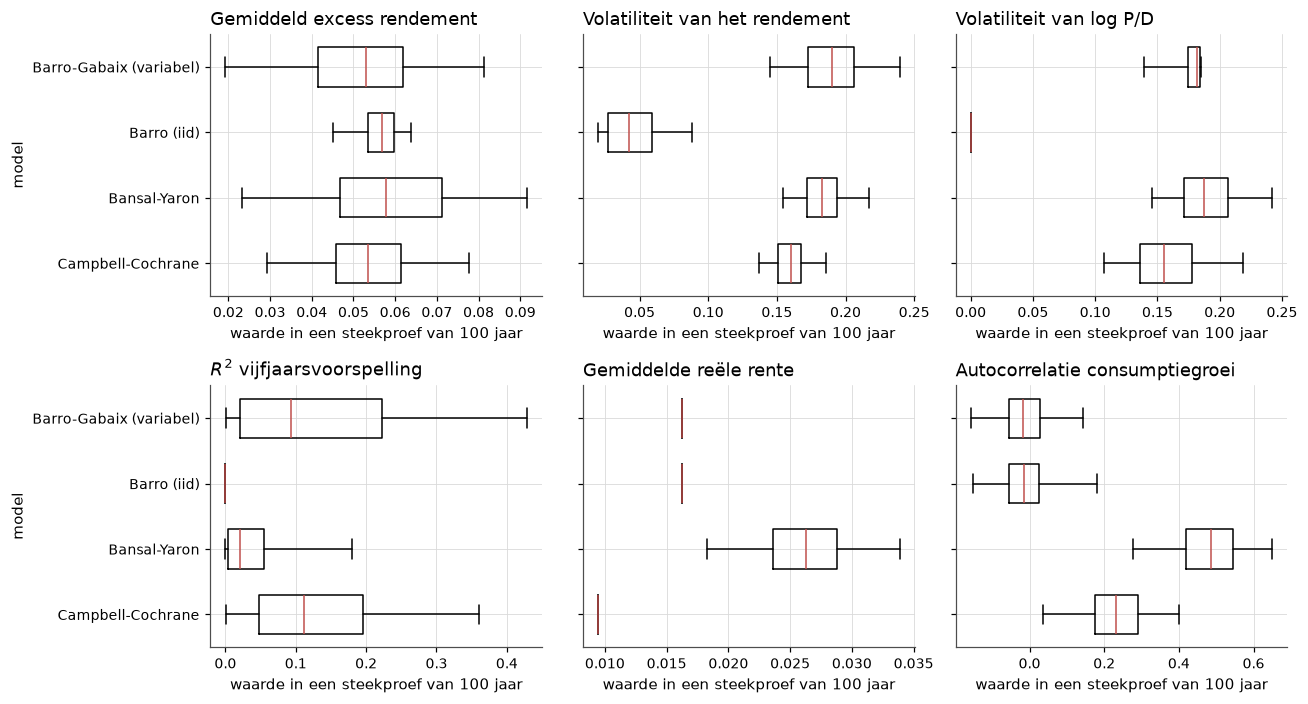

In [11]:
SHOW = {"E[R^e]": "Gemiddeld excess rendement", "sd(R)": "Volatiliteit van het rendement",
        "sd(log P/D)": "Volatiliteit van log P/D", "R2 5 jaar": "$R^2$ vijfjaarsvoorspelling",
        "E[R^f]": "Gemiddelde reële rente", "AC1(dc)": "Autocorrelatie consumptiegroei"}


def plot_bands(data=None):
    """Box plots of simulated 100-year sample moments per model; optional data values as vertical lines."""
    names = list(simulated)
    fig, axes = plt.subplots(2, 3, figsize=(12, 6.5))
    for i, (ax, (key, title)) in enumerate(zip(axes.flat, SHOW.items())):
        ax.boxplot([simulated[name][key] for name in names], whis=(2.5, 97.5), showfliers=False,
                   orientation="horizontal", widths=0.6)
        ax.set_yticks(range(1, len(names) + 1))
        ax.set_yticklabels(names if i % 3 == 0 else [""] * len(names))
        if data is not None:
            ax.axvline(data[key], color=hap.plotting.COLORS[1], lw=1.6, label="VS 1930–2025")
        ax.set_title(title)
        ax.set_xlabel("waarde in een steekproef van 100 jaar")
        ax.set_ylabel("model" if i % 3 == 0 else "")
    if data is not None:
        axes[0, 0].legend(loc="lower right")
    plt.tight_layout()
    plt.show()


plot_bands()

:::{figure} #cel-drie-antwoorden-banden
:label: fig-drie-antwoorden-banden
:width: 100%

Verdeling van zes momenten over duizend gesimuleerde steekproeven van honderd jaar
(doos: 25e–75e percentiel, snorharen: 2,5e–97,5e percentiel). De gemiddelde premie
van alle vier de modellen overlapt breed: honderd jaar data kunnen ze op dit moment
niet uit elkaar houden. De scheiding zit in momenten die de modellen wél verschillend
voorspellen maar die in de data zelf onnauwkeurig of slecht meetbaar zijn.
:::

De tabel en figuur zeggen drie dingen.

**De premie scheidt niets.** De medianen liggen voor alle vier de modellen tussen 5,3
en 5,8%, en de 95%-banden van de drie modellen met een realistische volatiliteit lopen
over vijf tot zeven procentpunt: Campbell-Cochrane 2,9–7,8%, Bansal-Yaron 2,3–9,2% en
de Gabaix-variant 1,9–8,1%. Dat is het 2%-motief: bij een rendementsvolatiliteit van
16–19% is de standaardfout van een honderdjarig gemiddelde 1,6–1,9 procentpunt, meer
dan de verschillen tussen de modellen. Alleen Barro met iid rampen heeft een smalle
band (4,5–6,4%), en dat is geen deugd: zijn rendementen schommelen nauwelijks.

**Tweede momenten scheiden wel, maar op kenmerken die de modellen als
bouwstenen hebben meegekregen.** De rente is constant in Campbell-Cochrane en de
rampenmodellen en licht beweeglijk in Bansal-Yaron; consumptiegroei is
autogecorreleerd in de maandmodellen, ongeveer 0,25 door tijdsaggregatie alleen,
0,5 in Bansal-Yaron door $x_t$, en rond nul in de jaarlijkse rampenmodellen. Barro
met iid rampen heeft een rendementsvolatiliteit van een paar procent — het
volatiliteitsprobleem dat Wachter noemde — en geen enkele beweging in de
prijs-dividend-ratio.

**Voorspelbaarheid scheidt zwak.** De $R^2$ van de vijfjaarsvoorspelling heeft in de
drie modellen met een bewegende prijs-dividend-ratio een band die bij nul begint en
doorloopt tot 0,18 (Bansal-Yaron), 0,36 (Campbell-Cochrane) of 0,43 (Gabaix-variant).
De medianen verschillen wel, 0,02 tegen 0,11 en 0,09, en dat is het theoretische
verschil uit de vorige sectie: in Bansal-Yaron beweegt de ratio vooral door verwachte
dividendgroei. Maar wie in honderd jaar data een $R^2$ van 0,1 vindt, kan daarmee geen
van de drie verwerpen.

## Replicatie op echte data

```{admonition} Replicatie
:class: seealso

**Bron.** John Y. Campbell en John H. Cochrane, *By Force of Habit*, Journal of
Political Economy 1999 {cite}`CampbellCochrane1999`, in de numerieke uitwerking van
Jessica Wachter, *Solving Models with External Habit*, Finance Research Letters 2005
{cite}`Wachter2005`; Ravi Bansal en Amir Yaron, *Risks for the Long Run*, Journal of
Finance 2004 {cite}`BansalYaron2004`, in de uitwerking van Jason Beeler en John
Campbell, Critical Finance Review 2012 {cite}`BeelerCampbell2012`; Robert Barro,
*Rare Disasters and Asset Markets in the Twentieth Century*, Quarterly Journal of
Economics 2006 {cite}`Barro2006`, in de samenvatting van Barro (2009)
{cite}`Barro2009`.

**Wat.** (1) Wachter (2005), tabel 2: de consumptieclaim van Campbell-Cochrane over
100 000 gesimuleerde jaren; op haar fijnste rooster een premie van 3,89–3,90%, een
volatiliteit van 8,2%, $\exp\E[p-d] = 34{,}5$ en $\sigma(p-d) = 0{,}13$, tegen 6,59%,
15,1%, 18,6 en 0,27 op het grofste rooster. (2) Beeler en Campbell (2012), tabel II,
kolom BY: populatiemomenten in logs, jaarlijks, $\E[r] = 6{,}62$,
$\sigma(r) = 16{,}88$, $\E[r^f] = 2{,}56$, $\sigma(r^f) = 1{,}30$,
$\E[p-d] = 3{,}00$, $\sigma(p-d) = 0{,}16$, $\sigma(\Delta c) = 2{,}92$ en
$\mathrm{AC1}(\Delta c) = 0{,}51$. (3) Barro (2009), tabel 3, rij $\gamma = \theta = 4$:
$r^f = 0{,}010$, $r^e = 0{,}069$, $\mathrm{PD} = 20{,}7$ — al gerepliceerd in de theorie.
(4) Geen tabel maar de centrale vraag: waar liggen de Amerikaanse data in de
simulatiebanden?

**Data hier.** Simulatie voor (1)–(3), met de parameters uit de bronnen. Voor (4):
`hap.data.goyal_welch("annual")` (S&P 500-totaalrendement `CRSP_SPvw`, `Rfree`,
`infl`, `D12`, `Index`) en reële consumptie per hoofd van niet-duurzame goederen
en diensten uit FRED via `hap.data.fred` (`PCNDA`, `PCESVA`, `DNDGRG3A086NBEA`,
`DSERRG3A086NBEA`, `B230RC0A052NBEA`), jaardata 1930–2025.

**Verschil met het origineel.** Barro's rampendataset is niet gratis via `hap`; we
gebruiken zijn gepubliceerde momenten ($p$, $\E b$, $\E(1-b)^{-4}$, $\E(1-b)^{-3}$) en
een vierpuntsverdeling op 15–64% die ze exact reproduceert. Campbell-Cochrane
simuleren wij met een dividendclaim waarvan we de correlatie (0,2) niet in hun tabel
hebben kunnen nalezen; de vergelijking met Wachter doen we op de consumptieclaim,
waar geen onzekere parameter in zit. Beeler en Campbell simuleren de
prijs-dividendverhouding als de maandelijkse verhouding; wij delen de
decemberprijs door de dividenden van het hele jaar, zoals Shiller en Goyal-Welch dat
in de data doen. De Gabaix-variant is een eigen vereenvoudiging met twee regimes.

**Verwachte afwijking.** (1) Onze consumptieclaim moet dicht bij Wachters fijnste
rooster liggen en ver van haar grofste: een premie tussen 3,5 en 4,5% en een
volatiliteit onder de 10%. (2) De BY-oplossing moet $\E[p-d]$, $\E[r^f]$,
$\sigma(r^f)$, $\sigma(\Delta c)$ en $\mathrm{AC1}(\Delta c)$ binnen 0,05 (in
procentpunt respectievelijk eenheden) reproduceren. (4) Het gemiddelde excess
rendement van de data moet binnen de 95%-band van ten minste drie modellen liggen,
en de volatiliteit van de log prijs-dividend-ratio moet boven de band van álle
modellen liggen. Valt de premie buiten alle banden of $\sigma(\log P/D)$ erbinnen,
dan zit er een fout in de code.
```

### Campbell-Cochrane en Bansal-Yaron naast hun bronnen

In [12]:
pop_cc = cc_simulate(cc_cons, 2000, 50)
lex_cc = np.log1p(pop_cc["rm"]) - np.log1p(pop_cc["rf"])
pop_by = by_simulate(by, 2000, 50)
z_month = by["A0m"] + by["A1m"] * 0 + by["A2m"] * BY["sig"] ** 2
sd_z = np.sqrt(by["A1m"] ** 2 * (BY["phi_e"] * BY["sig"]) ** 2 / (1 - BY["rho"] ** 2)
               + by["A2m"] ** 2 * BY["sig_w"] ** 2 / (1 - BY["nu1"] ** 2))

replication = pd.DataFrame(
    {
        "hier": [100 * (pop_cc["rm"] - pop_cc["rf"]).mean(), 100 * (pop_cc["rm"] - pop_cc["rf"]).std(),
                 np.exp(pop_cc["lpd"].mean()), pop_cc["lpd"].std(),
                 100 * np.log1p(pop_by["rm"]).mean(), 100 * np.log1p(pop_by["rm"]).std(),
                 100 * np.log1p(pop_by["rf"]).mean(), 100 * np.log1p(pop_by["rf"]).std(),
                 z_month - np.log(12), sd_z, 100 * pop_by["dc"].std(),
                 sample_moments(**pop_by)["AC1(dc)"].mean()],
        "bron": [3.90, 8.25, 34.52, 0.13, 6.62, 16.88, 2.56, 1.30, 3.00, 0.16, 2.92, 0.51],
    },
    index=pd.MultiIndex.from_tuples(
        [("CC consumptieclaim (Wachter 2005, tabel 2)", m) for m in ("E[R^e] %", "sd(R^e) %", "exp E[p-d]", "sd(p-d)")]
        + [("BY (Beeler-Campbell 2012, tabel II)", m) for m in
           ("E[r] %", "sd(r) %", "E[r^f] %", "sd(r^f) %", "E[p-d]", "sd(p-d), maandratio", "sd(dc) %", "AC1(dc)")]),
)
replication.round(3)

hier   bron
CC consumptieclaim (Wachter 2005, tabel 2) E[R^e] %              4.204   3.90
                                           sd(R^e) %             8.402   8.25
                                           exp E[p-d]           36.215  34.52
                                           sd(p-d)               0.129   0.13
BY (Beeler-Campbell 2012, tabel II)        E[r] %                6.756   6.62
                                           sd(r) %              16.874  16.88
                                           E[r^f] %              2.577   2.56
                                           sd(r^f) %             1.313   1.30
                                           E[p-d]                3.003   3.00
                                           sd(p-d), maandratio   0.161   0.16
                                           sd(dc) %              2.929   2.92
                                           AC1(dc)               0.519   0.51

In [13]:
def fred_annual(code):
    series = hap_data.fred(code)[code]
    series.index = series.index.year
    return series


real_cons = (fred_annual("PCNDA") / fred_annual("DNDGRG3A086NBEA")
             + fred_annual("PCESVA") / fred_annual("DSERRG3A086NBEA")) / fred_annual("B230RC0A052NBEA")
gw = hap_data.goyal_welch("annual")
gw.index = gw.index.year
data_real = pd.DataFrame(
    {
        "rm": (1 + gw["CRSP_SPvw"]) / (1 + gw["infl"]) - 1,
        "rf": (1 + gw["Rfree"]) / (1 + gw["infl"]) - 1,
        "lpd": np.log(gw["Index"] / gw["D12"]),
        "dc": np.log(real_cons).diff(),
    }
).loc[1930:2025].dropna()
data_moments = {k: float(v[0]) for k, v in sample_moments(*(data_real[c].to_numpy()[:, None]
                                                              for c in ("rm", "rf", "lpd", "dc"))).items()}
T_data = len(data_real)
se_premium = (data_real["rm"] - data_real["rf"]).std() / np.sqrt(T_data)
print(f"{data_real.index[0]}-{data_real.index[-1]}, {T_data} jaar; SE van het gemiddelde excess rendement = {se_premium:.3f}")

placement = pd.DataFrame(
    {model: {k: np.mean(mom[k] <= data_moments[k]) for k in MOMENTS} for model, mom in simulated.items()}
)
placement.insert(0, "data 1930-2025", pd.Series(data_moments))
placement.round(3)

1930-2025, 96 jaar; SE van het gemiddelde excess rendement = 0.020


,data 1930-2025,Campbell-Cochrane,Bansal-Yaron,Barro (iid),Barro-Gabaix (variabel)
E[R^e],0.083,0.990,0.929,1.000,0.981
sd(R),0.194,0.994,0.746,1.000,0.568
E[R^f],0.003,0.000,0.000,0.000,0.000
sd(R^f),0.038,1.000,1.000,1.000,1.000
E[P/D],35.924,0.967,1.000,1.000,1.000
sd(log P/D),0.510,1.000,1.000,1.000,1.000
R2 1 jaar,0.013,0.201,0.689,1.000,0.323
R2 5 jaar,0.133,0.570,0.931,1.000,0.589
AC1(dc),0.375,0.952,0.145,0.996,1.000


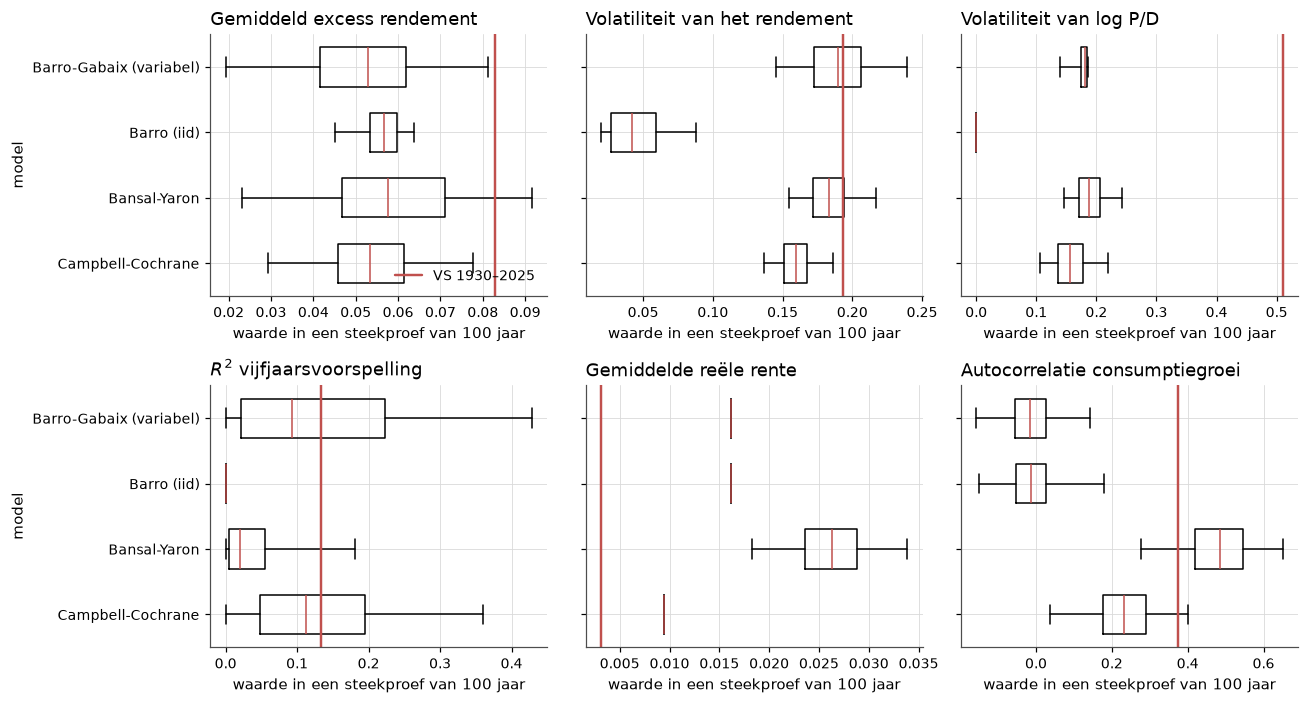

In [14]:
plot_bands(data_moments)

:::{figure} #cel-drie-antwoorden-data
:label: fig-drie-antwoorden-data
:width: 100%

De simulatiebanden uit [](#fig-drie-antwoorden-banden) met de Amerikaanse jaardata
1930–2025 als verticale lijn. Voor rendementsvolatiliteit en voorspelbaarheid ligt
de lijn binnen de banden van meerdere modellen tegelijk. De gemiddelde premie ligt
aan de bovenkant en alleen binnen de band van Bansal-Yaron; de volatiliteit van de
prijs-dividend-ratio ligt ver buiten alle banden.
:::

### Wat de replicatie laat zien

**De bronnen.** De consumptieclaim van Campbell-Cochrane geeft ons een premie van
4,20% met een volatiliteit van 8,40%, $\exp\E[p-d] = 36{,}2$ en $\sigma(p-d) = 0{,}129$,
tegen 3,90%, 8,25%, 34,5 en 0,13 op Wachters fijnste rooster en 6,59%, 15,05%, 18,6 en
0,27 op haar grofste. De verwachting komt uit: we liggen dicht bij de fijne en ver
van de grove oplossing. Dat we drie tiende procentpunt boven haar fijnste rooster uitkomen, valt binnen
wat een roosterkeuze doet: oefening 2 laat zien dat alleen al de ondergrens van het
rooster de premie met meer dan een procentpunt verschuift. Voor
Bansal-Yaron liggen alle vijf de beloofde momenten binnen 0,05 van tabel II van
Beeler en Campbell: $\E[p-d] = 3{,}00$, $\E[r^f] = 2{,}58\%$, $\sigma(r^f) = 1{,}31\%$,
$\sigma(\Delta c) = 2{,}93\%$ en een autocorrelatie van 0,52 tegen 0,51. Het gemiddelde
log-rendement ligt met 6,76% een zevende procentpunt hoger dan hun 6,62%, wat wij
toeschrijven aan het optellen van gelineariseerde maandrendementen. Opvallend is de rente van 2,6%: een latere kalibratie die Beeler en Campbell ook evalueren, verhoogt $\beta$ naar 0,9989 per maand en brengt de rente zo naar 0,99%.

**De premie: de verwachting komt maar half uit.** Het gemiddelde excess rendement over 1930–2025 is 8,3% met een standaardfout van 2,0 procentpunt. Dat ligt binnen de 95%-band van Bansal-Yaron (percentiel 0,93), net boven die van Campbell-Cochrane (0,99) en de Gabaix-variant (0,98), en ver boven Barro met iid rampen. De belofte "binnen de band van ten minste drie modellen" wordt dus niet gehaald. Een codefout is het niet — alle medianen liggen tussen 5,3 en 5,8% — maar een hoge Amerikaanse premie, hoger dan de 6,69% van 1947–1995 waarop Campbell en Cochrane kalibreerden. Het 2%-motief werkt hier in twee richtingen: het 95%-interval rond de data, 4,3–12,3%, bevat de mediaan van elk model, terwijl de simulatiebanden smal genoeg zijn om twee modellen net te verwerpen. Voor Barro is een hoog Amerikaans gemiddelde bovendien een voorspelling: in een land zonder ramp is het gerealiseerde rendement hoger dan de ware premie (5,67 tegen 4,92 procentpunt in het toy-voorbeeld).

**De prijs-dividend-ratio: geen van de drie.** De volatiliteit van de log-ratio is in de
data 0,51, tegen banden die ophouden bij 0,22 (Campbell-Cochrane), 0,24 (Bansal-Yaron)
en 0,19 (Gabaix-variant). Dat was de verwachting, en het is het duidelijkste feit in de
tabel. Beeler en Campbell merken op dat de volatiliteit in de data zo hoog is deels
omdat prijzen aan het eind van de steekproef hoog bleven; tot 1998 vonden zij 0,36,
nog steeds boven hun model. Alle drie de modellen verklaren een bewegende
prijs-dividend-ratio, geen van drie verklaart hoeveel hij beweegt.

**Voorspelbaarheid en volatiliteit: observationele equivalentie.** De $R^2$ van de
vijfjaarsvoorspelling is in de data 0,13, op het 57e percentiel voor Campbell-Cochrane,
het 59e voor de Gabaix-variant en het 93e voor Bansal-Yaron; bij één jaar zijn de
percentielen 0,20, 0,32 en 0,69. De rendementsvolatiliteit van 19,4% ligt binnen de
banden van Bansal-Yaron en de Gabaix-variant. Op deze momenten zijn de modellen in de
zin van [](#prf-drie-antwoorden-equivalentie) niet te onderscheiden. De rente in de
data (0,3% met een volatiliteit van 3,8%) ligt onder en boven alle banden, maar dat is
voor een deel inflatieruis in een nominaal risicovrij rendement.

**Consumptie: zwak tegen Bansal-Yaron.** De eerste autocorrelatie van jaarlijkse consumptiegroei is 0,375: het 15e percentiel van Bansal-Yaron en het 95e van Campbell-Cochrane, dus door beide getolereerd. De rampenmodellen verwerpen de waarde, maar zij zijn jaarlijks gesimuleerd, zonder de tijdsaggregatie die al ongeveer 0,25 oplevert. Oefening 3 laat zien hoe sterk dit moment van de steekproef afhangt.

## Wat er brak, en wat daarna kwam

**Wat de modellen verklaren.** Veel. Twintig jaar na Mehra en Prescott lieten drie modellen zien dat een consumptie-SDF een premie van ruim 5% kan dragen met een volatiliteit van 16–19%, een lage rente en een prijs-dividend-ratio die rendementen voorspelt. De puzzel verschoof van "onmogelijk met redelijke voorkeuren" naar "mogelijk met één extra parameter".

**Waar het breekt.** Op twee meetbare punten die we zelf hebben nagerekend. Het eerste
is een feit dat geen van drie haalt: de volatiliteit van de log prijs-dividend-ratio is
in de data 0,51, en de 97,5e percentielen van de modellen liggen tussen 0,19 en 0,24.
Het tweede is het omgekeerde probleem: op de momenten die ze wél halen —
voorspelbaarheid, volatiliteit, en binnen de onzekerheid van het gemiddelde ook de
premie — halen ze het tegelijk. Honderd jaar data scheiden de modellen niet, en de
parameters die ze scheiden ($\phi$, $\rho$, $p$) zijn met diezelfde data niet te meten.
Zelfs de getallen van één model zijn fragiel: dezelfde kalibratie van Campbell-Cochrane
geeft 6,6% of 3,9% premie, afhankelijk van het rooster {cite}`Wachter2005`.

**Risico of vergissing?** De Chicago-lezing is dat alle drie de modellen hetzelfde
zeggen op een andere plek: de premie is een beloning voor beprijsd risico, en de
beweging in prijzen is beweging in discontovoeten. Welk risico het is, doet voor
een belegger minder ter zake dan dát het risico is; wie in een crisis aandelen
koopt, verkoopt verzekering aan wie ze op dat moment het hardst nodig heeft. De
Yale-lezing is dat een model met een parameter die niet te verifiëren is, niets
verklaart wat een gedragsmodel met extrapolerende of angstige beleggers niet ook
verklaart, en dat het deel van de prijsbeweging dat geen van drie haalt, de vergissing
is. De data die de lezingen zouden scheiden, bestaan maar zijn schaars: prijzen van
verzekering tegen de staart, en directe metingen van wat beleggers verwachten. Het
praktijkmotief van Santa-Clara geeft de toets voor wie belegt: het rendement uit een
crisis is een risicopremie als het risico echt kan toeslaan, en een vermeend inzicht
als de belegger denkt dat het niet meer gebeurt.

**Wat er daarna kwam.** Epistemisch is de equity premium hier definitief een
feit-met-concurrerende-theorieën geworden. De volgende stap zocht de scheiding in
activa waarvan de looptijd bekend is: de termijnstructuur van rentes en haar
risicopremies, in [](#05-28-termijnstructuur-premies).

## Oefeningen

:::{exercise}
:label: ex-drie-antwoorden-1

**Wanneer telt de EIS voor de premie?** Neem Epstein-Zin-voorkeuren.

1. Laat voor een iid lognormale economie zien dat $\log m_{t+1} = c - \gamma\,\Delta c_{t+1}$,
   bepaal $\kappa$ uit $\E[m R_w] = 1$, en leid de formules voor $\log R^f$ en
   $\log(\E[R_w]/R^f)$ uit het toy-voorbeeld af.
2. Bereken met `ez_iid` en de jaarversie van de Bansal-Yaron-kalibratie
   ($\beta^{12}$, $12\mu$, $\sqrt{12}\,\bar\sigma$, $\gamma = 10$) de iid-rente en -premie
   voor $\psi \in \{1{,}25;\ 1{,}5;\ 2\}$.
3. Bereken met `by_solve` voor dezelfde $\psi$ de premie via het langetermijnkanaal
   uit [](#eq-drie-antwoorden-by-premie). Waarom hangt de premie hier wél van $\psi$ af?
:::

:::{solution} ex-drie-antwoorden-1
:class: dropdown

**(1)** Met $r_w = \Delta c + \kappa$ is
$\log m = \theta\log\beta + (\theta-1)\kappa + (-\theta/\psi + \theta - 1)\Delta c$, en de
coëfficiënt is $\theta(1-1/\psi) - 1 = -\gamma$. De Euler-vergelijking voor de
vermogensclaim, $\E[e^{\log m + r_w}] = 1$, geeft
$\theta\log\beta + \theta\kappa + (1-\gamma)\mu + \tfrac12(1-\gamma)^2\sigma^2 = 0$, dus
$\kappa = -\log\beta - [(1-\gamma)\mu + \tfrac12(1-\gamma)^2\sigma^2]/\theta$. De constante
in $\log m$ is dan $c = \log\beta - (1/\psi - \gamma)[\mu + \tfrac12(1-\gamma)\sigma^2]$,
en $\log R^f = -c + \gamma\mu - \tfrac12\gamma^2\sigma^2$ werkt uit tot de formule in de
tekst. Voor de premie: $\log\E[R_w] - \log R^f = -\Cov(\log m, r_w) = \gamma\sigma^2$.

**(2) en (3)**

In [15]:
psi_rows = {}
for psi in (1.25, 1.5, 2.0):
    sol_psi = by_solve({**BY, "psi": psi})
    log_rf_iid, prem_iid = ez_iid(BY["beta"] ** 12, 12 * BY["mu"], np.sqrt(12) * BY["sig"], BY["gamma"], psi)
    psi_rows[psi] = {
        "iid: log R^f": log_rf_iid,
        "iid: log premie": prem_iid,
        "BY: A_1,m": sol_psi["A1m"],
        "BY: premie via x_t (%/jaar)": 1200 * sol_psi["lam_e"] * sol_psi["k1m"] * sol_psi["A1m"] * BY["phi_e"] * BY["sig"] ** 2,
    }
pd.DataFrame(psi_rows).T.rename_axis("psi").round(4)

,iid: log R^f,iid: log premie,"BY: A_1,m",BY: premie via x_t (%/jaar)
psi,,,,
1.25,0.0321,0.0073,87.7721,4.9485
1.50,0.0302,0.0073,93.2178,5.3371
2.00,0.0277,0.0073,100.0431,5.8374


Bij iid groei verschuift $\psi$ alleen de rente; de premie is voor elke $\psi$
$\gamma\sigma^2 = 0{,}73\%$. In Bansal-Yaron bepaalt $\psi$ via
$A_{1,m} = (\phi - 1/\psi)/(1 - \kappa_{1,m}\rho)$ hoe sterk de prijs op nieuws over
$x_t$ reageert, en via $\theta$ en $A_1$ hoe zwaar dat nieuws in de SDF weegt; een hogere
EIS vergroot beide. Wat de oefening leert: de ontkoppeling van Epstein en Zin lost de
rentepuzzel op, maar de premie komt pas als de toekomst voorspelbaar is — en daarmee
hangt het model aan $\rho$.
:::

:::{exercise}
:label: ex-drie-antwoorden-2

**Het rooster als donkere materie.** Wachter {cite}`Wachter2005` liet zien dat de
getallen van Campbell en Cochrane van het rooster afhangen. Los de consumptieclaim op
met roosters die doorlopen tot $\bar s - 8$, $\bar s - 20$ en $\bar s - 80$, en met een
grof rooster van dertig punten tot $\bar s - 8$. Simuleer telkens 2000 jaar maal 50
paden en rapporteer premie, volatiliteit, $\exp\E[p-d]$ en $\sigma(p-d)$, naast
Wachters fijnste en grofste rooster.
:::

:::{solution} ex-drie-antwoorden-2
:class: dropdown

In [16]:
grid_variants = {
    "tot s-bar - 8": dict(lower=8.0),
    "tot s-bar - 20": dict(lower=20.0),
    "tot s-bar - 80 (hoofdtekst)": dict(lower=80.0),
    "grof: 30 punten tot s-bar - 8": dict(lower=8.0, n_low=10, n_high=20),
}
grid_rows = {}
for label, kw in grid_variants.items():
    sim = cc_simulate(cc_solve(**{**CC, "sig_w": 0.0, "rho_w": 0.0}, **kw), 2000, 50)
    excess = sim["rm"] - sim["rf"]
    grid_rows[label] = {"E[R^e] %": 100 * excess.mean(), "sd(R^e) %": 100 * excess.std(),
                        "exp E[p-d]": np.exp(sim["lpd"].mean()), "sd(p-d)": sim["lpd"].std()}
grid_rows["Wachter (2005), fijnste rooster"] = {"E[R^e] %": 3.90, "sd(R^e) %": 8.25, "exp E[p-d]": 34.52, "sd(p-d)": 0.13}
grid_rows["Wachter (2005), grofste rooster"] = {"E[R^e] %": 6.59, "sd(R^e) %": 15.05, "exp E[p-d]": 18.62, "sd(p-d)": 0.27}
pd.DataFrame(grid_rows).T.round(3)

,E[R^e] %,sd(R^e) %,exp E[p-d],sd(p-d)
tot s-bar - 8,2.831,5.774,60.728,0.082
tot s-bar - 20,3.586,7.232,44.034,0.108
tot s-bar - 80 (hoofdtekst),4.198,8.453,36.117,0.129
grof: 30 punten tot s-bar - 8,2.720,6.173,66.012,0.089
"Wachter (2005), fijnste rooster",3.900,8.250,34.520,0.130
"Wachter (2005), grofste rooster",6.590,15.050,18.620,0.270


Hoe verder het rooster naar lage waarden van het surplus doorloopt, hoe hoger de premie
(2,8%, 3,6% en 4,2%) en de volatiliteit: een rooster dat afkapt, knipt de slechtste
toestanden af, en juist die dragen in dit model de premie. Het aantal punten doet er
minder toe dan de ondergrens; ons grove rooster van dertig punten geeft 2,7%. Wachters
grofste rooster gaf juist een veel hogere premie, 6,6%, dus haar roosters behandelden de
staart anders dan de onze; hoe precies, hebben we niet kunnen nalezen. Wat de oefening leert: in een model
waarvan de premie uit zeldzame, extreme toestanden komt, is ook de numerieke oplossing
een parameter die niemand in de data kan controleren.
:::

:::{exercise}
:label: ex-drie-antwoorden-3

**Andere steekproeven.** Herhaal de plaatsing van de data in de simulatiebanden voor
1947–2025 en voor 1930–1998 (het einde van de steekproef van Bansal en Yaron), met
simulaties van dezelfde lengte als de steekproef, voor het gemiddelde excess
rendement, $\sigma(\log P/D)$, de vijfjaars-$R^2$ en de autocorrelatie van
consumptiegroei. Welke conclusies uit de hoofdtekst veranderen?
:::

:::{solution} ex-drie-antwoorden-3
:class: dropdown

In [17]:
def placement_for(first, last, n_samples=300):
    """Data moments for first..last and their percentile in simulations of the same length."""
    sub = data_real.loc[first:last]
    T = len(sub)
    data_m = {k: float(v[0]) for k, v in sample_moments(*(sub[c].to_numpy()[:, None]
                                                         for c in ("rm", "rf", "lpd", "dc"))).items()}
    sims = {"Campbell-Cochrane": sample_moments(**cc_simulate(cc_div, T, n_samples)),
            "Bansal-Yaron": sample_moments(**by_simulate(by, T, n_samples)),
            "Barro-Gabaix (variabel)": sample_moments(**disaster_simulate(T, n_samples, GABAIX))}
    keys = ["E[R^e]", "sd(log P/D)", "R2 5 jaar", "AC1(dc)"]
    rows = {"data": {k: data_m[k] for k in keys}}
    rows.update({name: {k: np.mean(mom[k] <= data_m[k]) for k in keys} for name, mom in sims.items()})
    return pd.DataFrame(rows)


pd.concat({"1947-2025": placement_for(1947, 2025), "1930-1998": placement_for(1930, 1998)},
          names=["steekproef", "moment"]).round(3)

data  Campbell-Cochrane  Bansal-Yaron  \
steekproef moment                                                
1947-2025  E[R^e]       0.088              0.997         0.923   
           sd(log P/D)  0.472              1.000         1.000   
           R2 5 jaar    0.119              0.520         0.897   
           AC1(dc)      0.168              0.267         0.003   
1930-1998  E[R^e]       0.084              0.983         0.850   
           sd(log P/D)  0.369              1.000         1.000   
           R2 5 jaar    0.302              0.863         0.990   
           AC1(dc)      0.489              1.000         0.520   

                        Barro-Gabaix (variabel)  
steekproef moment                                
1947-2025  E[R^e]                         0.997  
           sd(log P/D)                    1.000  
           R2 5 jaar                      0.513  
           AC1(dc)                        0.953  
1930-1998  E[R^e]                         0.970  
           sd(log P/D)                    1.000  
           R2 5 jaar                      0.827  
           AC1(dc)                        1.000

Twee conclusies blijven staan: $\sigma(\log P/D)$ ligt in beide steekproeven boven
alle banden (0,47 en 0,37), en de premie ligt alleen binnen de band van Bansal-Yaron.
De consumptieconclusie draait om. Naoorlogs is de autocorrelatie van consumptiegroei
0,17, op het 0,3e percentiel van Bansal-Yaron: op deze steekproef wordt het model
verworpen. Tot 1998, met de jaren dertig erin, is ze 0,49 en ligt ze op de mediaan van
Bansal-Yaron en boven de band van Campbell-Cochrane. Wat de oefening leert: het moment
dat de modellen het scherpst scheidt, hangt aan een handvol Depressiejaren — het punt
van Beeler en Campbell — en daarom blijven ze op de volledige steekproef
observationeel equivalent.
:::